# Compare SFT Trajectory Context Length

Compare token counts across different SFT trajectory files.

In [2]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandarallel import pandarallel
from transformers import AutoTokenizer

os.environ['TOKENIZERS_PARALLELISM'] = 'true'
pandarallel.initialize(progress_bar=True, verbose=1, nb_workers=16)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')

In [48]:
# === Configure files to compare ===
# Each entry: (label, path)
SFT_BASE = '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train'

FILES = [
    ('Oracle (before curation)',
     f'{SFT_BASE}/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/sft/oracle_traj_128k_swegym_all_794i.jsonl'),
    ('Oracle (after curation)',
     f'{SFT_BASE}/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/sft/oracle_traj_128k_swegym_all_794i_curated.jsonl'),
    ('Oracle (after dedup)',
     f'/home/v-murongma/code/oracle_generated_curation/curation_runs/oracle_traj_128k_swegym_all_794i_20260420_035513/oracle_traj_128k_swegym_all_794i_curated_dedup.jsonl'),
    ('Policy (Qwen3-Coder, resolved)',
     f'{SFT_BASE}/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft/policy_traj_128k_swegym_resolved_634i.jsonl'),
    ('Policy (Qwen3-Coder, resolved, reduced reasoning)',
     f'{SFT_BASE}/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft/policy_traj_128k_swegym_resolved_634i_reduce_reasoning_r0.5_max250.jsonl'),
    ('Policy (GLM-5-FP8, resolved)',
     f'{SFT_BASE}/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-train-glm5_fp8_t05-run_1/sft/policy_traj_128k_swegym_resolved_798i.jsonl'),
]

# Verify all files exist
for label, path in FILES:
    exists = os.path.exists(path)
    size = os.path.getsize(path) / 1e6 if exists else 0
    print(f"{'OK' if exists else 'MISSING':7s} {size:7.1f}MB  {label}")

OK        160.4MB  Oracle (before curation)
OK        156.2MB  Oracle (after curation)
OK         87.7MB  Oracle (after dedup)
OK        158.0MB  Policy (Qwen3-Coder, resolved)
OK        155.1MB  Policy (Qwen3-Coder, resolved, reduced reasoning)
OK        225.3MB  Policy (GLM-5-FP8, resolved)


In [49]:
def _tokenize_msgs(messages):
    """Count tokens using the chat template (pandarallel-compatible)."""
    normalized = []
    for msg in messages:
        m = dict(msg)
        c = m.get('content', '') or ''
        if isinstance(c, list):
            c = '\n'.join(p['text'] for p in c if isinstance(p, dict) and p.get('type') == 'text')
        m['content'] = c
        normalized.append(m)
    return len(tokenizer.apply_chat_template(normalized))


def load_file(path: str, label: str) -> pd.DataFrame:
    rows = []
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            msgs = d['messages']
            n_msgs = len(msgs)
            n_asst = sum(1 for m in msgs if m['role'] == 'assistant')
            rows.append({
                'label': label,
                'messages': msgs,
                'n_messages': n_msgs,
                'n_assistant': n_asst,
            })
    return pd.DataFrame(rows)


# Load all files
dfs = []
for label, path in FILES:
    print(f'Loading {label}...')
    df = load_file(path, label)
    dfs.append(df)
    print(f'  {len(df)} trajectories')

df_all = pd.concat(dfs, ignore_index=True)

# Tokenize in parallel
print(f'\nTokenizing {len(df_all)} trajectories...')
df_all['n_tokens'] = df_all['messages'].parallel_apply(_tokenize_msgs)
df_all.drop(columns=['messages'], inplace=True)

for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    print(f'  {label}: median={subset["n_tokens"].median():.0f} tokens')

print(f'\nTotal: {len(df_all)} trajectories')

Loading Oracle (before curation)...
  794 trajectories
Loading Oracle (after curation)...
  793 trajectories
Loading Oracle (after dedup)...
  433 trajectories
Loading Policy (Qwen3-Coder, resolved)...
  634 trajectories
Loading Policy (Qwen3-Coder, resolved, reduced reasoning)...
  634 trajectories
Loading Policy (GLM-5-FP8, resolved)...
  798 trajectories

Tokenizing 4086 trajectories...


  Oracle (before curation): median=44780 tokens
  Oracle (after curation): median=44330 tokens
  Oracle (after dedup): median=45241 tokens
  Policy (Qwen3-Coder, resolved): median=53631 tokens
  Policy (Qwen3-Coder, resolved, reduced reasoning): median=53168 tokens
  Policy (GLM-5-FP8, resolved): median=64866 tokens

Total: 4086 trajectories


In [50]:
# Summary statistics
summary = df_all.groupby('label')['n_tokens'].describe().round(0)
summary['total'] = df_all.groupby('label')['n_tokens'].count()
display(summary[['total', 'mean', '50%', 'min', 'max', 'std']])

,total,mean,50%,min,max,std
label,,,,,,
Oracle (after curation),793,46936.0,44330.0,18819.0,124282.0,14851.0
Oracle (after dedup),433,47892.0,45241.0,22692.0,106092.0,14297.0
Oracle (before curation),794,47542.0,44780.0,18843.0,124953.0,15082.0
"Policy (GLM-5-FP8, resolved)",798,65543.0,64866.0,26820.0,124390.0,13937.0
"Policy (Qwen3-Coder, resolved)",634,56543.0,53631.0,25152.0,122078.0,17422.0
"Policy (Qwen3-Coder, resolved, reduced reasoning)",634,56138.0,53168.0,24889.0,121594.0,17371.0


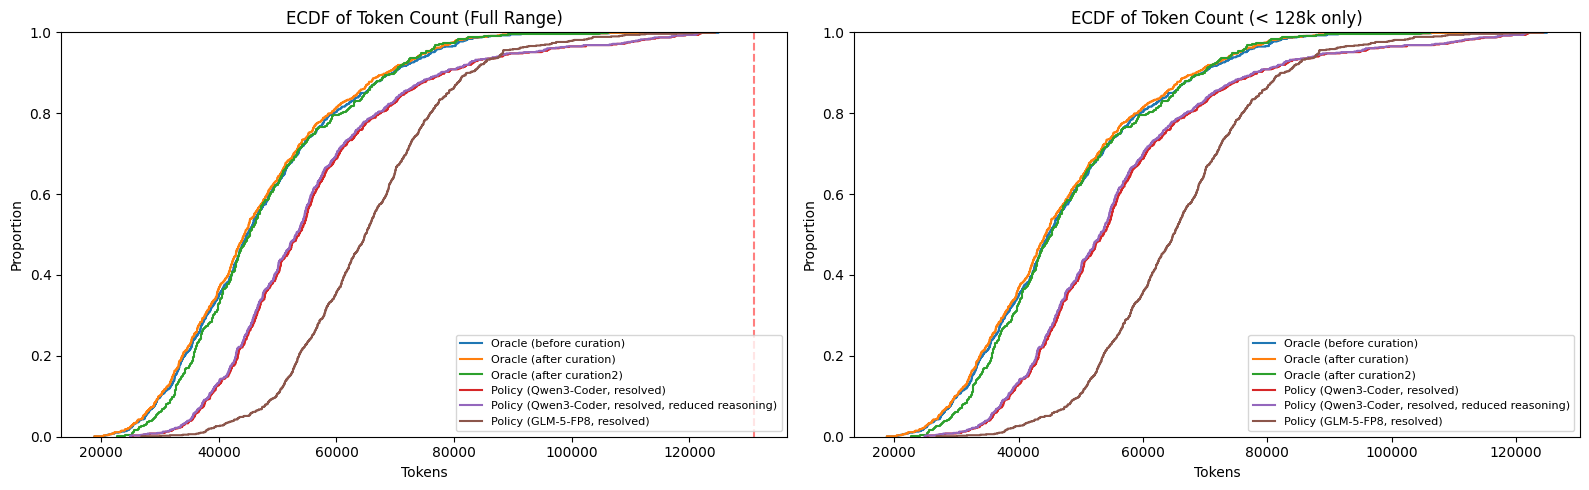

In [30]:
# ECDF plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full range
ax = axes[0]
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    sns.ecdfplot(data=subset, x='n_tokens', ax=ax, label=label)
ax.set_title('ECDF of Token Count (Full Range)')
ax.set_xlabel('Tokens')
ax.legend(fontsize=8)
ax.axvline(x=131072, color='red', linestyle='--', alpha=0.5, label='128k')

# Zoomed to 128k
ax = axes[1]
df_128k = df_all[df_all['n_tokens'] < 131072]
for label in df_128k['label'].unique():
    subset = df_128k[df_128k['label'] == label]
    sns.ecdfplot(data=subset, x='n_tokens', ax=ax, label=label)
ax.set_title('ECDF of Token Count (< 128k only)')
ax.set_xlabel('Tokens')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

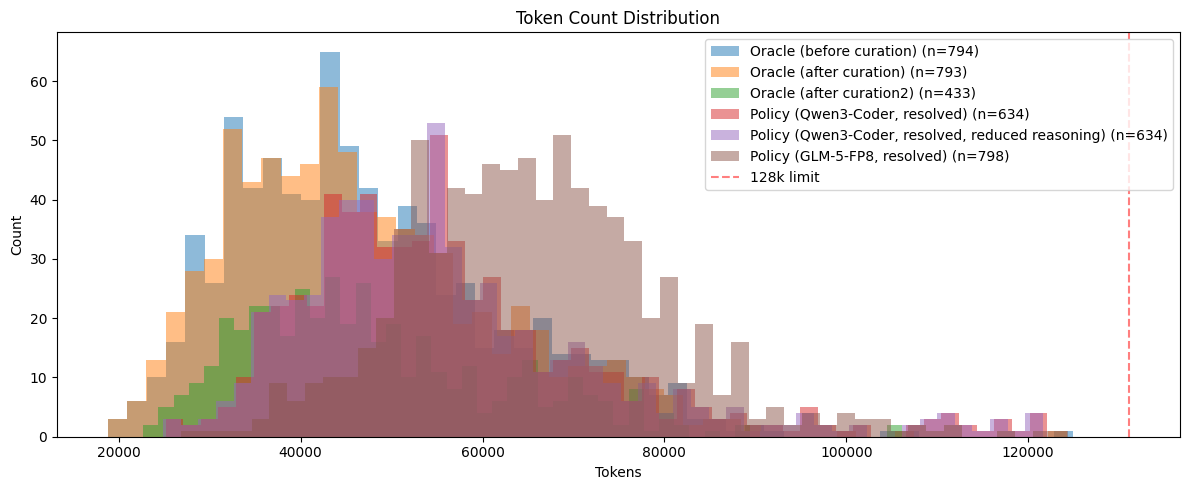

In [31]:
# Histogram overlay
fig, ax = plt.subplots(figsize=(12, 5))
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    ax.hist(subset['n_tokens'], bins=50, alpha=0.5, label=f"{label} (n={len(subset)})")
ax.set_title('Token Count Distribution')
ax.set_xlabel('Tokens')
ax.set_ylabel('Count')
ax.axvline(x=131072, color='red', linestyle='--', alpha=0.5, label='128k limit')
ax.legend()
plt.tight_layout()
plt.show()

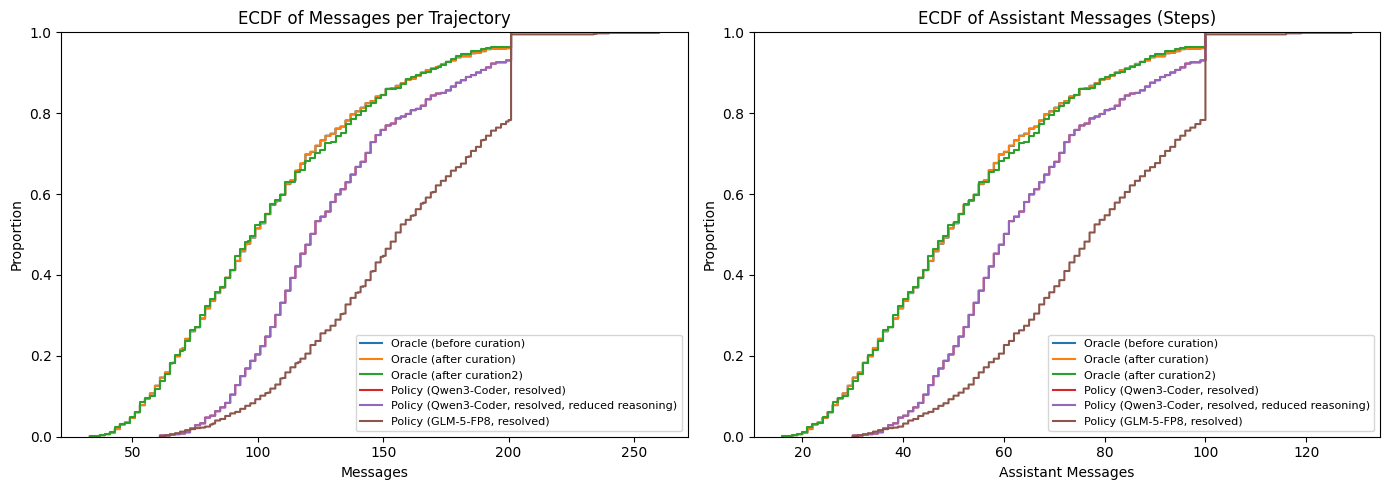

In [32]:
# Messages per trajectory
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    sns.ecdfplot(data=subset, x='n_messages', ax=ax, label=label)
ax.set_title('ECDF of Messages per Trajectory')
ax.set_xlabel('Messages')
ax.legend(fontsize=8)

ax = axes[1]
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    sns.ecdfplot(data=subset, x='n_assistant', ax=ax, label=label)
ax.set_title('ECDF of Assistant Messages (Steps)')
ax.set_xlabel('Assistant Messages')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

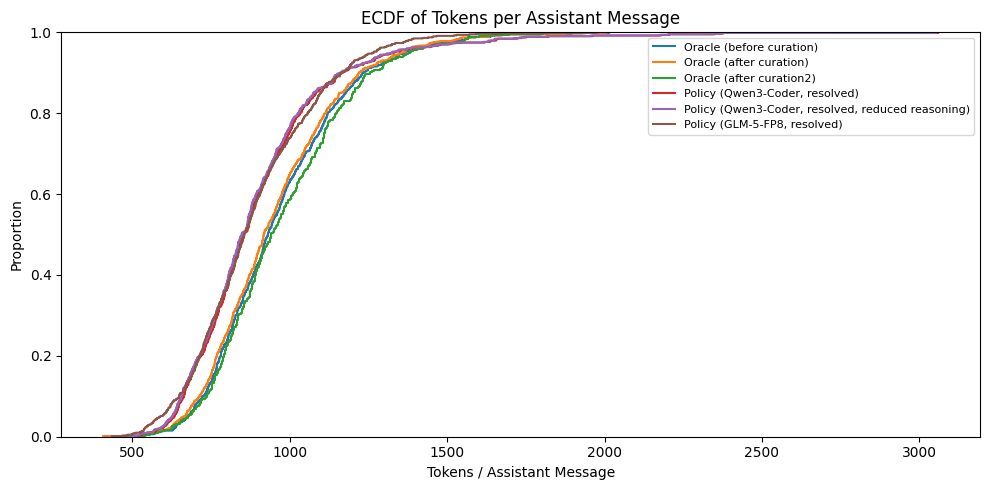

                                                   count   mean    std    min  \
label                                                                           
Oracle (after curation)                            793.0  952.0  217.0  407.0   
Oracle (after curation2)                           433.0  978.0  221.0  470.0   
Oracle (before curation)                           794.0  964.0  218.0  407.0   
Policy (GLM-5-FP8, resolved)                       798.0  886.0  208.0  434.0   
Policy (Qwen3-Coder, resolved)                     634.0  904.0  256.0  479.0   
Policy (Qwen3-Coder, resolved, reduced reasoning)  634.0  897.0  256.0  472.0   

                                                     25%    50%     75%  \
label                                                                     
Oracle (after curation)                            796.0  917.0  1077.0   
Oracle (after curation2)                           815.0  940.0  1110.0   
Oracle (before curation)                           

In [33]:
# Tokens per assistant message (reasoning density)
df_all['tokens_per_asst'] = df_all['n_tokens'] / df_all['n_assistant']

fig, ax = plt.subplots(figsize=(10, 5))
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    sns.ecdfplot(data=subset, x='tokens_per_asst', ax=ax, label=label)
ax.set_title('ECDF of Tokens per Assistant Message')
ax.set_xlabel('Tokens / Assistant Message')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(df_all.groupby('label')['tokens_per_asst'].describe().round(0))

# SFT Quality: Loop-Inducing Pattern Analysis

Check three patterns that cause models to get stuck in loops after SFT:
1. **Bare tool calls** — assistant emits `<function=...>` with zero reasoning before it
2. **Ignored failures** — after a command fails (exit code 1), assistant doesn't acknowledge the error
3. **Repeated messages** — exact duplicate assistant messages and multi-step loop sequences

In [34]:
import re
from collections import Counter

def analyze_quality(path: str, label: str) -> dict:
    """Analyze loop-inducing patterns in an SFT trajectory file."""
    total_trajs = 0
    total_asst = 0

    # Pattern 1: bare tool calls
    bare_total = 0
    bare_runs = []  # lengths of consecutive bare-call runs

    # Pattern 2: ignored failures
    total_after_failure = 0
    ignored_failures = 0

    # Pattern 3: repeated messages & multi-step loops
    trajs_with_exact_repeats = 0
    total_exact_repeats = 0
    trajs_with_multi_loops = 0

    with open(path) as f:
        for line in f:
            d = json.loads(line)
            msgs = d['messages']
            total_trajs += 1

            current_bare_run = 0
            seen_sigs = {}
            has_repeat = False
            prev_call_sig = None

            for i, m in enumerate(msgs):
                if m['role'] != 'assistant':
                    # Pattern 2: check if this is a failure observation
                    if m['role'] == 'user' and 'exit code 1' in m.get('content', ''):
                        if i + 1 < len(msgs) and msgs[i + 1]['role'] == 'assistant':
                            total_after_failure += 1
                            next_c = msgs[i + 1].get('content', '')
                            fn_idx = next_c.find('<function=')
                            reasoning = next_c[:fn_idx].strip() if fn_idx >= 0 else next_c.strip()
                            ack_words = ['fail', 'error', 'not found', 'exit code', "didn't",
                                         "doesn't", 'no result', 'empty', 'try', 'different',
                                         'instead', 'another', 'adjust', 'issue', 'problem',
                                         'wrong', 'fix', 'correct', 'change']
                            if not any(w in reasoning.lower() for w in ack_words):
                                ignored_failures += 1
                    prev_call_sig = None
                    if current_bare_run > 0:
                        bare_runs.append(current_bare_run)
                        current_bare_run = 0
                    continue

                total_asst += 1
                content = m.get('content', '')
                fn_idx = content.find('<function=')

                # Pattern 1: bare tool call
                is_bare = fn_idx >= 0 and len(content[:fn_idx].strip()) == 0
                if is_bare:
                    bare_total += 1
                    current_bare_run += 1
                else:
                    if current_bare_run > 0:
                        bare_runs.append(current_bare_run)
                        current_bare_run = 0

                # Pattern 3: exact duplicate
                sig = content[:200]
                if sig in seen_sigs:
                    total_exact_repeats += 1
                    has_repeat = True
                seen_sigs[sig] = seen_sigs.get(sig, 0) + 1

            if current_bare_run > 0:
                bare_runs.append(current_bare_run)
            if has_repeat:
                trajs_with_exact_repeats += 1

            # Pattern 3b: multi-step loops (A→B→A→B in message content)
            seq = [m.get('content', '')[:300] for m in msgs]
            has_loop = False
            for window in [2, 4, 6]:
                for j in range(len(seq) - window * 2):
                    if seq[j:j + window] == seq[j + window:j + window * 2]:
                        has_loop = True
                        break
                if has_loop:
                    break
            if has_loop:
                trajs_with_multi_loops += 1

    bare_run_dist = Counter(bare_runs)
    runs_3plus = sum(1 for r in bare_runs if r >= 3)
    runs_5plus = sum(1 for r in bare_runs if r >= 5)

    return {
        'label': label,
        'trajs': total_trajs,
        'asst_msgs': total_asst,
        'bare_calls': bare_total,
        'bare_pct': 100 * bare_total / max(total_asst, 1),
        'bare_runs_3+': runs_3plus,
        'bare_runs_5+': runs_5plus,
        'bare_max_run': max(bare_runs) if bare_runs else 0,
        'failures_total': total_after_failure,
        'failures_ignored': ignored_failures,
        'failures_ignored_pct': 100 * ignored_failures / max(total_after_failure, 1),
        'trajs_with_repeats': trajs_with_exact_repeats,
        'trajs_with_repeats_pct': 100 * trajs_with_exact_repeats / max(total_trajs, 1),
        'exact_repeats': total_exact_repeats,
        'trajs_with_loops': trajs_with_multi_loops,
        'trajs_with_loops_pct': 100 * trajs_with_multi_loops / max(total_trajs, 1),
    }


# Run analysis on all configured files
quality_results = []
for label, path in FILES:
    print(f'Analyzing {label}...')
    result = analyze_quality(path, label)
    quality_results.append(result)

df_quality = pd.DataFrame(quality_results).set_index('label')
print('Done.')

Analyzing Oracle (before curation)...
Analyzing Oracle (after curation)...
Analyzing Oracle (after curation2)...
Analyzing Policy (Qwen3-Coder, resolved)...
Analyzing Policy (Qwen3-Coder, resolved, reduced reasoning)...
Analyzing Policy (GLM-5-FP8, resolved)...
Done.


In [11]:
# Summary table
display_cols = {
    'trajs': 'Trajectories',
    'asst_msgs': 'Asst Msgs',
    'bare_calls': 'Bare Calls',
    'bare_pct': 'Bare %',
    'bare_runs_3+': 'Bare Runs≥3',
    'bare_runs_5+': 'Bare Runs≥5',
    'bare_max_run': 'Max Bare Run',
    'failures_total': 'After Failures',
    'failures_ignored': 'Ignored',
    'failures_ignored_pct': 'Ignored %',
    'trajs_with_repeats': 'Trajs w/ Repeats',
    'trajs_with_repeats_pct': 'Repeat %',
    'exact_repeats': 'Exact Repeats',
    'trajs_with_loops': 'Multi-step Loops',
    'trajs_with_loops_pct': 'Loop %',
}

df_display = df_quality[list(display_cols.keys())].rename(columns=display_cols)
for col in df_display.columns:
    if '%' in col:
        df_display[col] = df_display[col].map('{:.1f}'.format)
display(df_display)

,Trajectories,Asst Msgs,Bare Calls,Bare %,Bare Runs≥3,Bare Runs≥5,Max Bare Run,After Failures,Ignored,Ignored %,Trajs w/ Repeats,Repeat %,Exact Repeats,Multi-step Loops,Loop %
label,,,,,,,,,,,,,,,
Oracle (before curation),794,41288,14142,34.3,0,0,1,2727,932,34.2,485,61.1,1413,77,9.7
Oracle (after curation),793,41226,13516,32.8,0,0,1,2727,983,36.0,351,44.3,986,39,4.9
"Policy (Qwen3-Coder, resolved)",634,40722,10967,26.9,0,0,1,2445,917,37.5,382,60.3,948,7,1.1
"Policy (Qwen3-Coder, resolved, reduced reasoning)",634,40722,22921,56.3,0,0,1,2445,1422,58.2,563,88.8,2054,12,1.9
"Policy (GLM-5-FP8, resolved)",798,61398,33979,55.3,0,0,1,3799,2552,67.2,746,93.5,4840,94,11.8


/tmp/ipykernel_1988978/1941445139.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


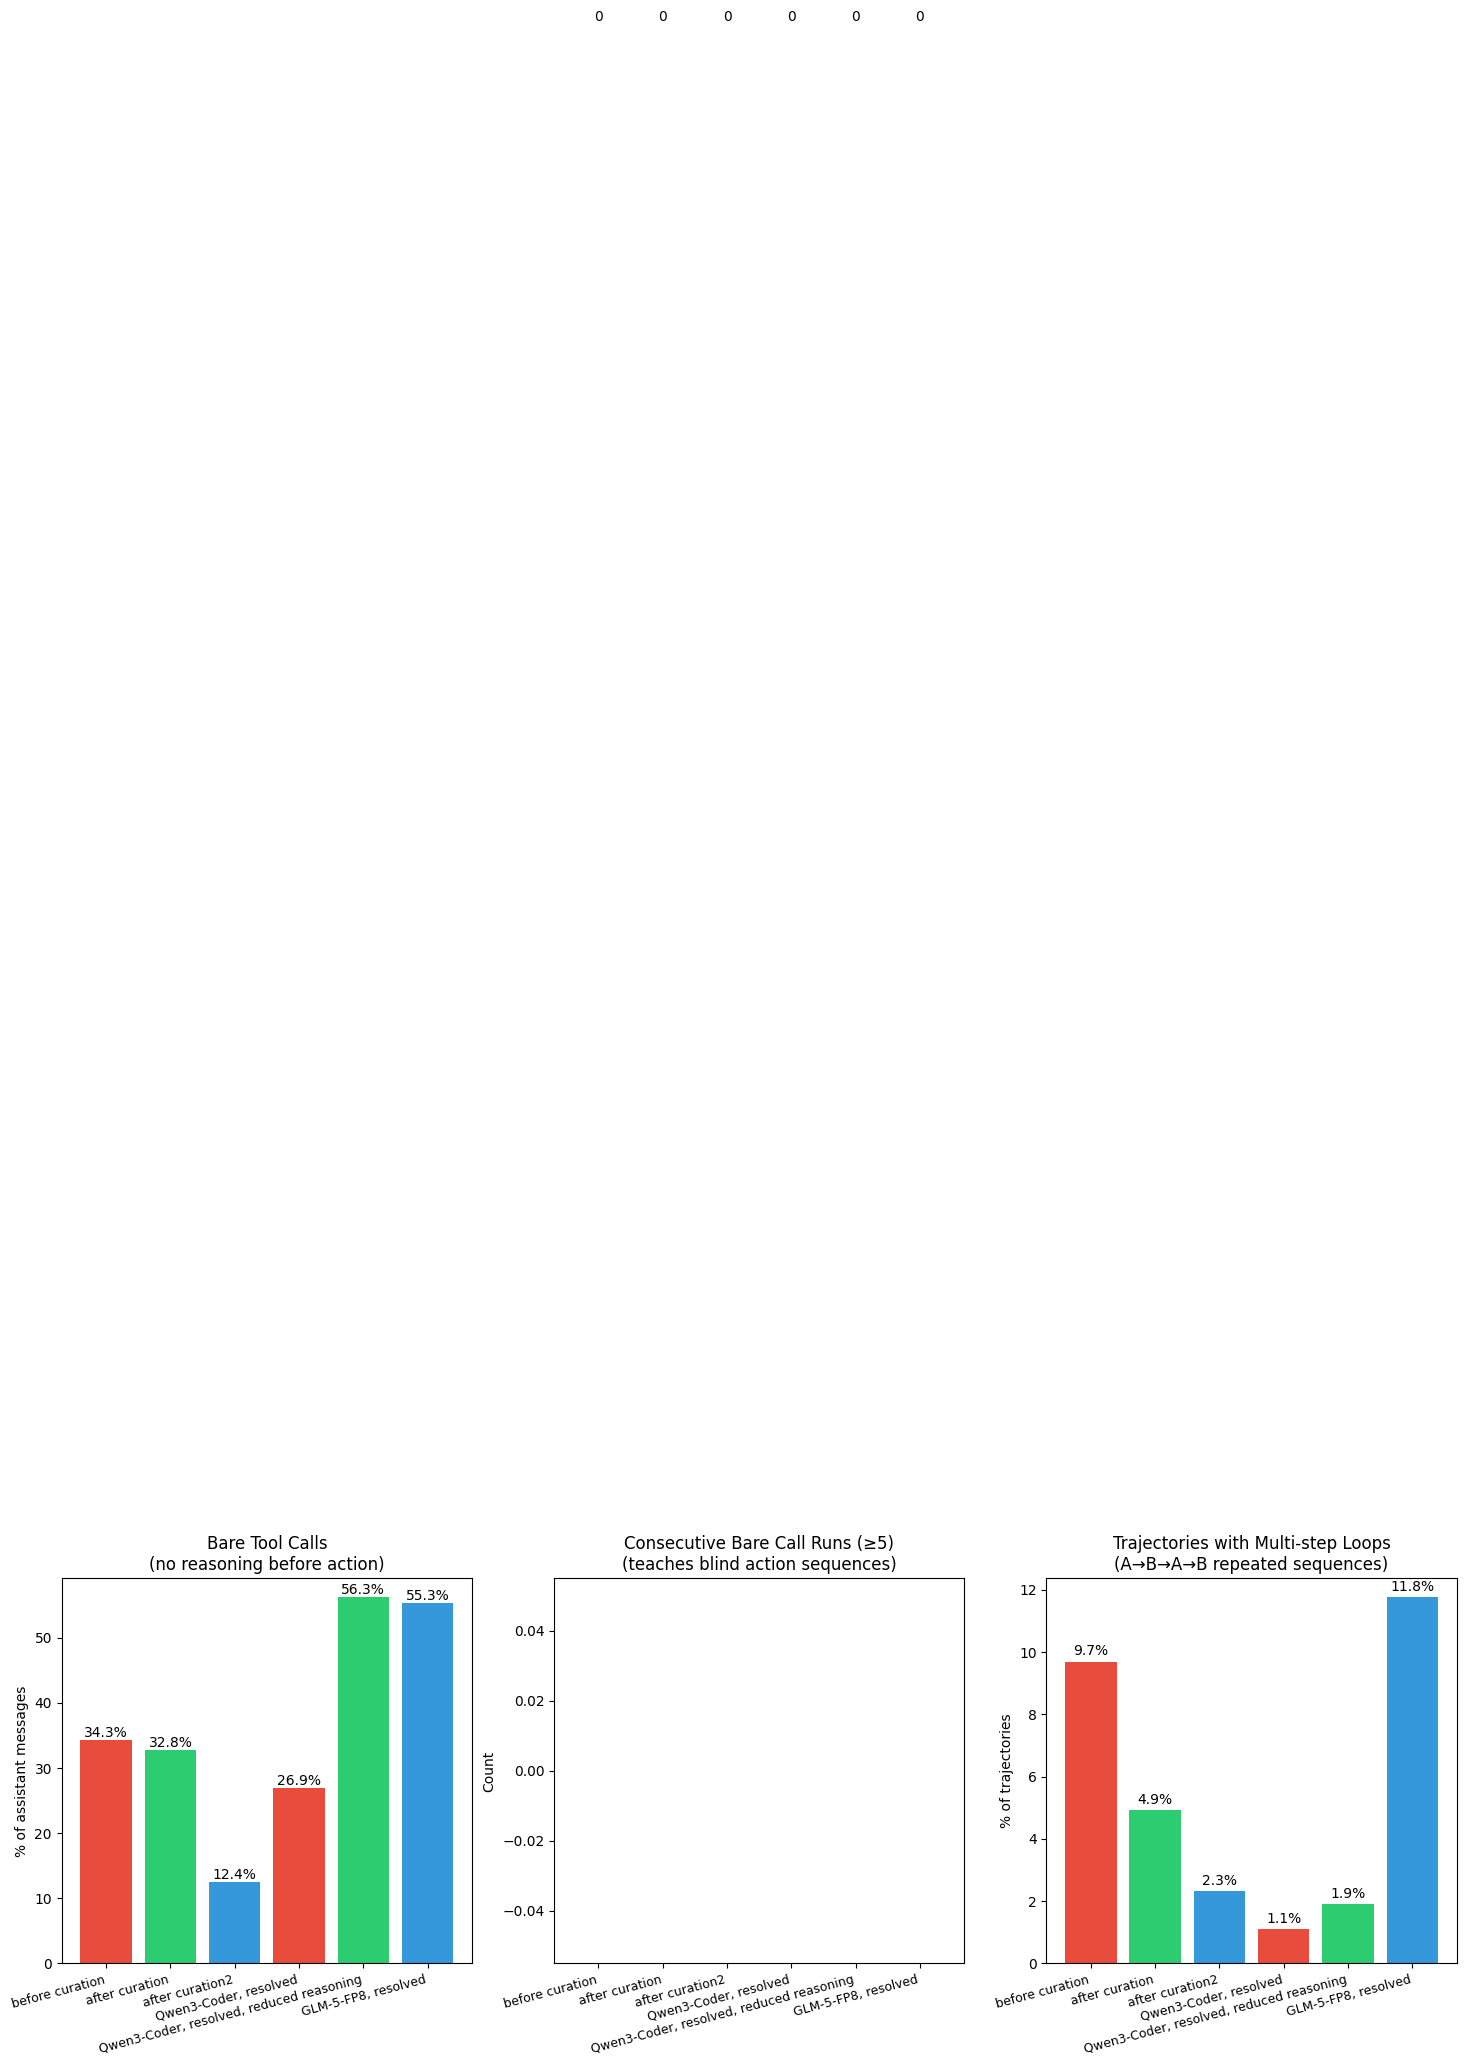

In [35]:
# Bar charts comparing key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = df_quality.index.tolist()
x = range(len(labels))
short_labels = [l.split('(')[1].rstrip(')') if '(' in l else l for l in labels]

# 1. Bare tool call %
ax = axes[0]
vals = df_quality['bare_pct'].values
bars = ax.bar(x, vals, color=['#e74c3c', '#2ecc71', '#3498db'][:len(labels)])
ax.set_ylabel('% of assistant messages')
ax.set_title('Bare Tool Calls\n(no reasoning before action)')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=15, ha='right', fontsize=9)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=10)

# 2. Bare runs of 5+
ax = axes[1]
vals = df_quality['bare_runs_5+'].values
bars = ax.bar(x, vals, color=['#e74c3c', '#2ecc71', '#3498db'][:len(labels)])
ax.set_ylabel('Count')
ax.set_title('Consecutive Bare Call Runs (≥5)\n(teaches blind action sequences)')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=15, ha='right', fontsize=9)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v}', ha='center', fontsize=10)

# 3. Multi-step loops
ax = axes[2]
vals = df_quality['trajs_with_loops_pct'].values
bars = ax.bar(x, vals, color=['#e74c3c', '#2ecc71', '#3498db'][:len(labels)])
ax.set_ylabel('% of trajectories')
ax.set_title('Trajectories with Multi-step Loops\n(A→B→A→B repeated sequences)')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=15, ha='right', fontsize=9)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Deep Dive: Reasoning Quality & Loop Root-Cause Analysis

Per-trajectory analysis of:
1. **Zero-reasoning streaks** — consecutive assistant messages with no text before the tool call
2. **Reasoning length distribution** — how much the model "thinks" before acting
3. **Explore vs Edit ratio** — is the model stuck reading or actually making changes?
4. **Instance-level comparison** — for overlapping tasks, which data source is more efficient?

In [36]:
import re
from collections import Counter


def _get_content(msg):
    """Normalize message content to string."""
    c = msg.get('content', '') or ''
    if isinstance(c, list):
        c = '\n'.join(p.get('text', '') for p in c if isinstance(p, dict))
    return c


def deep_quality_analysis(path: str, label: str) -> dict:
    """Per-trajectory deep quality analysis."""
    trajs = []
    with open(path) as f:
        for line in f:
            trajs.append(json.loads(line))

    all_reasoning_lens = []
    zero_reasoning_streak_maxes = []
    explore_counts = []
    edit_counts = []
    mostly_bare_count = 0
    instance_stats = {}

    for traj in trajs:
        msgs = traj['messages']

        # Extract instance ID from task message
        inst_id = None
        if len(msgs) >= 2:
            task_text = _get_content(msgs[1])
            match = re.search(r'/workspace/([^\s<]+)', task_text)
            if match:
                inst_id = match.group(1)

        asst_count = 0
        bare_count = 0
        current_zero_streak = 0
        max_zero_streak = 0
        traj_reasoning_lens = []
        traj_explore = 0
        traj_edit = 0

        for m in msgs:
            if m['role'] != 'assistant':
                if current_zero_streak > 0:
                    max_zero_streak = max(max_zero_streak, current_zero_streak)
                    current_zero_streak = 0
                continue

            asst_count += 1
            content = _get_content(m)
            fn_idx = content.find('<function=')

            if fn_idx >= 0:
                reasoning = content[:fn_idx].strip()
                reasoning_len = len(reasoning)
                traj_reasoning_lens.append(reasoning_len)
                all_reasoning_lens.append(reasoning_len)

                if reasoning_len == 0:
                    bare_count += 1
                    current_zero_streak += 1
                else:
                    max_zero_streak = max(max_zero_streak, current_zero_streak)
                    current_zero_streak = 0

                # Classify action: explore vs edit
                fn_end = content.find('>', fn_idx)
                tool_name = content[fn_idx + 10:fn_end].split('{')[0].strip() if fn_end >= 0 else ''

                if tool_name == 'str_replace_editor':
                    cmd_match = re.search(r'<parameter=command>(.*?)</parameter', content, re.DOTALL)
                    cmd = cmd_match.group(1).strip() if cmd_match else ''
                    if cmd == 'view':
                        traj_explore += 1
                    else:
                        traj_edit += 1
                elif tool_name == 'execute_bash':
                    cmd_match = re.search(r'<parameter=command>(.*?)</parameter', content, re.DOTALL)
                    cmd = cmd_match.group(1).strip() if cmd_match else ''
                    if any(w in cmd for w in ['grep ', 'find ', 'cat ', 'ls ', 'head ', 'tail ', 'wc ']):
                        traj_explore += 1
                    else:
                        traj_edit += 1
                elif tool_name in ('think', 'task_tracker'):
                    pass  # meta actions
                else:
                    traj_edit += 1
            else:
                all_reasoning_lens.append(len(content.strip()))

        max_zero_streak = max(max_zero_streak, current_zero_streak)
        zero_reasoning_streak_maxes.append(max_zero_streak)
        explore_counts.append(traj_explore)
        edit_counts.append(traj_edit)

        if asst_count > 0 and bare_count / asst_count > 0.5:
            mostly_bare_count += 1

        if inst_id:
            import statistics as _stats
            instance_stats[inst_id] = {
                'n_asst': asst_count,
                'bare_pct': 100 * bare_count / max(asst_count, 1),
                'avg_reasoning': (_stats.mean(traj_reasoning_lens)
                                  if traj_reasoning_lens else 0),
                'max_zero_streak': max_zero_streak,
                'explore': traj_explore,
                'edit': traj_edit,
            }

    import statistics as _stats
    total = len(trajs)
    return {
        'label': label,
        'trajs': total,
        # Reasoning lengths
        'reasoning_median': _stats.median(all_reasoning_lens) if all_reasoning_lens else 0,
        'reasoning_mean': _stats.mean(all_reasoning_lens) if all_reasoning_lens else 0,
        'reasoning_p10': sorted(all_reasoning_lens)[int(0.1 * len(all_reasoning_lens))] if all_reasoning_lens else 0,
        'reasoning_p90': sorted(all_reasoning_lens)[int(0.9 * len(all_reasoning_lens))] if all_reasoning_lens else 0,
        'zero_reasoning_pct': 100 * sum(1 for r in all_reasoning_lens if r == 0) / max(len(all_reasoning_lens), 1),
        'short_reasoning_pct': 100 * sum(1 for r in all_reasoning_lens if r < 20) / max(len(all_reasoning_lens), 1),
        # Zero-reasoning streaks
        'streak_median': _stats.median(zero_reasoning_streak_maxes),
        'streak_mean': _stats.mean(zero_reasoning_streak_maxes),
        'streak_p90': sorted(zero_reasoning_streak_maxes)[int(0.9 * len(zero_reasoning_streak_maxes))],
        'streak_p95': sorted(zero_reasoning_streak_maxes)[int(0.95 * len(zero_reasoning_streak_maxes))],
        'streak_max': max(zero_reasoning_streak_maxes),
        'streak_ge5_pct': 100 * sum(1 for s in zero_reasoning_streak_maxes if s >= 5) / total,
        'streak_ge10_pct': 100 * sum(1 for s in zero_reasoning_streak_maxes if s >= 10) / total,
        'streak_ge20_pct': 100 * sum(1 for s in zero_reasoning_streak_maxes if s >= 20) / total,
        # Mostly bare
        'mostly_bare_pct': 100 * mostly_bare_count / total,
        # Explore vs edit
        'total_explore': sum(explore_counts),
        'total_edit': sum(edit_counts),
        'explore_ratio': 100 * sum(explore_counts) / max(sum(explore_counts) + sum(edit_counts), 1),
        # Instance-level stats for cross-comparison
        '_instance_stats': instance_stats,
    }


# Run on all configured files
deep_results = []
for label, path in FILES:
    print(f'Analyzing {label}...')
    deep_results.append(deep_quality_analysis(path, label))
print('Done.')

Analyzing Oracle (before curation)...
Analyzing Oracle (after curation)...
Analyzing Oracle (after curation2)...
Analyzing Policy (Qwen3-Coder, resolved)...
Analyzing Policy (Qwen3-Coder, resolved, reduced reasoning)...
Analyzing Policy (GLM-5-FP8, resolved)...
Done.


In [37]:
# === Summary table: Reasoning quality ===
display_cols_deep = {
    'trajs': 'Trajs',
    'reasoning_median': 'Reason Med',
    'reasoning_mean': 'Reason Mean',
    'reasoning_p10': 'Reason P10',
    'reasoning_p90': 'Reason P90',
    'zero_reasoning_pct': 'Zero %',
    'short_reasoning_pct': 'Short<20 %',
    'streak_median': 'Streak Med',
    'streak_mean': 'Streak Mean',
    'streak_p90': 'Streak P90',
    'streak_max': 'Streak Max',
    'streak_ge5_pct': '≥5 Streak %',
    'streak_ge10_pct': '≥10 Streak %',
    'streak_ge20_pct': '≥20 Streak %',
    'mostly_bare_pct': 'Mostly Bare %',
    'explore_ratio': 'Explore %',
}

df_deep = pd.DataFrame([{k: v for k, v in r.items() if k != '_instance_stats'}
                         for r in deep_results]).set_index('label')
df_deep_display = df_deep[list(display_cols_deep.keys())].rename(columns=display_cols_deep)
for col in df_deep_display.columns:
    if '%' in col or 'Mean' in col or 'Med' in col:
        df_deep_display[col] = df_deep_display[col].map('{:.1f}'.format)
display(df_deep_display)

,Trajs,Reason Med,Reason Mean,Reason P10,Reason P90,Zero %,Short<20 %,Streak Med,Streak Mean,Streak P90,Streak Max,≥5 Streak %,≥10 Streak %,≥20 Streak %,Mostly Bare %,Explore %
label,,,,,,,,,,,,,,,,
Oracle (before curation),794,87.0,221.3,0,686,34.3,34.3,1.0,1.0,1,1,0.0,0.0,0.0,7.8,58.8
Oracle (after curation),793,91.0,172.3,0,496,32.8,32.8,1.0,1.0,1,1,0.0,0.0,0.0,6.6,58.8
Oracle (after curation2),433,113.0,239.8,0,670,12.4,12.6,1.0,0.7,1,1,0.0,0.0,0.0,1.6,59.8
"Policy (Qwen3-Coder, resolved)",634,73.0,164.3,0,341,26.9,27.3,1.0,1.0,1,1,0.0,0.0,0.0,0.0,48.8
"Policy (Qwen3-Coder, resolved, reduced reasoning)",634,0.0,135.6,0,341,56.3,56.5,1.0,1.0,1,1,0.0,0.0,0.0,81.2,48.8
"Policy (GLM-5-FP8, resolved)",798,0.0,52.1,0,106,55.4,55.4,1.0,1.0,1,1,0.0,0.0,0.0,58.5,54.0


/tmp/ipykernel_1988978/3654705464.py:78: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


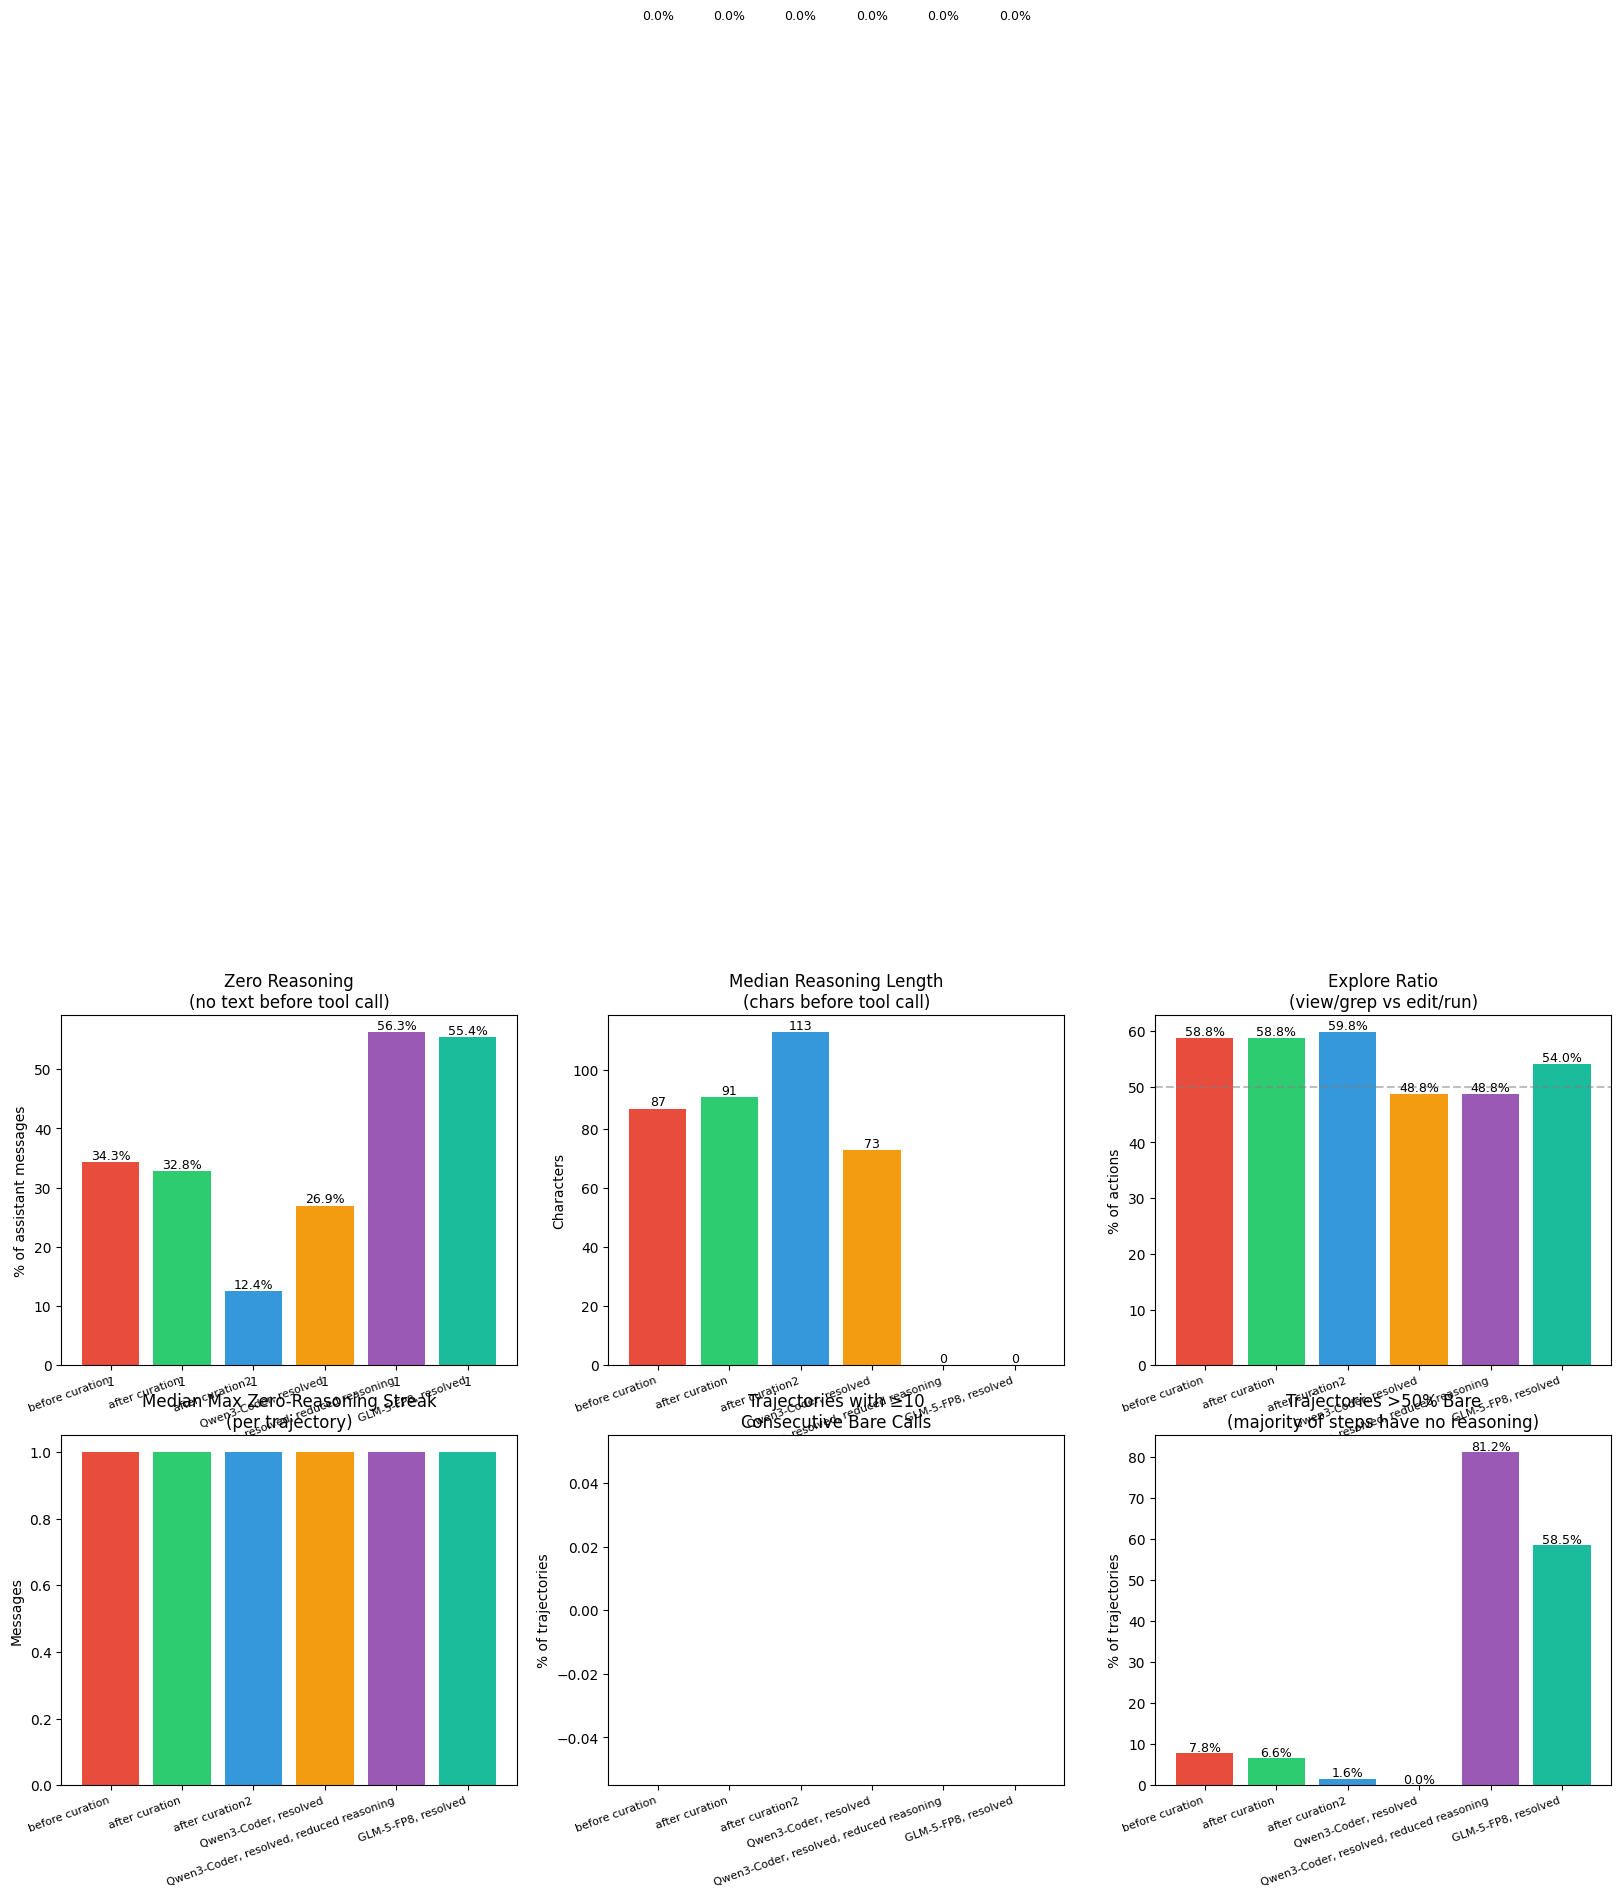

In [38]:
# === Visualization: Zero-reasoning streaks & reasoning length ===
labels_deep = [r['label'] for r in deep_results]
short_labels_deep = [l.split('(')[1].rstrip(')') if '(' in l else l for l in labels_deep]
x_deep = range(len(labels_deep))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c'][:len(labels_deep)]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 1: Reasoning quality
ax = axes[0, 0]
vals = [r['zero_reasoning_pct'] for r in deep_results]
bars = ax.bar(x_deep, vals, color=colors)
ax.set_ylabel('% of assistant messages')
ax.set_title('Zero Reasoning\n(no text before tool call)')
ax.set_xticks(list(x_deep))
ax.set_xticklabels(short_labels_deep, rotation=20, ha='right', fontsize=8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=9)

ax = axes[0, 1]
vals = [r['reasoning_median'] for r in deep_results]
bars = ax.bar(x_deep, vals, color=colors)
ax.set_ylabel('Characters')
ax.set_title('Median Reasoning Length\n(chars before tool call)')
ax.set_xticks(list(x_deep))
ax.set_xticklabels(short_labels_deep, rotation=20, ha='right', fontsize=8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{v:.0f}', ha='center', fontsize=9)

ax = axes[0, 2]
vals = [r['explore_ratio'] for r in deep_results]
bars = ax.bar(x_deep, vals, color=colors)
ax.set_ylabel('% of actions')
ax.set_title('Explore Ratio\n(view/grep vs edit/run)')
ax.set_xticks(list(x_deep))
ax.set_xticklabels(short_labels_deep, rotation=20, ha='right', fontsize=8)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=9)

# Row 2: Streak analysis
ax = axes[1, 0]
vals = [r['streak_median'] for r in deep_results]
bars = ax.bar(x_deep, vals, color=colors)
ax.set_ylabel('Messages')
ax.set_title('Median Max Zero-Reasoning Streak\n(per trajectory)')
ax.set_xticks(list(x_deep))
ax.set_xticklabels(short_labels_deep, rotation=20, ha='right', fontsize=8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{v:.0f}', ha='center', fontsize=9)

ax = axes[1, 1]
vals = [r['streak_ge10_pct'] for r in deep_results]
bars = ax.bar(x_deep, vals, color=colors)
ax.set_ylabel('% of trajectories')
ax.set_title('Trajectories with ≥10\nConsecutive Bare Calls')
ax.set_xticks(list(x_deep))
ax.set_xticklabels(short_labels_deep, rotation=20, ha='right', fontsize=8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=9)

ax = axes[1, 2]
vals = [r['mostly_bare_pct'] for r in deep_results]
bars = ax.bar(x_deep, vals, color=colors)
ax.set_ylabel('% of trajectories')
ax.set_title('Trajectories >50% Bare\n(majority of steps have no reasoning)')
ax.set_xticks(list(x_deep))
ax.set_xticklabels(short_labels_deep, rotation=20, ha='right', fontsize=8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
# === Instance-level pairwise comparison (all pairs with overlap) ===
import itertools
import statistics

pair_results = []

for (r_a, r_b) in itertools.combinations(deep_results, 2):
    stats_a = r_a['_instance_stats']
    stats_b = r_b['_instance_stats']
    overlap = set(stats_a.keys()) & set(stats_b.keys())
    if len(overlap) < 5:
        continue  # skip pairs with too few common instances

    a_fewer = sum(1 for inst in overlap if stats_a[inst]['n_asst'] < stats_b[inst]['n_asst'])
    b_fewer = sum(1 for inst in overlap if stats_b[inst]['n_asst'] < stats_a[inst]['n_asst'])
    a_more_reasoning = sum(1 for inst in overlap
                           if stats_a[inst]['avg_reasoning'] > stats_b[inst]['avg_reasoning'])
    step_diffs = [stats_b[inst]['n_asst'] - stats_a[inst]['n_asst'] for inst in overlap]

    pair_results.append({
        'A': r_a['label'],
        'B': r_b['label'],
        'overlap': len(overlap),
        'A fewer steps %': f"{100 * a_fewer / len(overlap):.1f}",
        'B fewer steps %': f"{100 * b_fewer / len(overlap):.1f}",
        'A more reasoning %': f"{100 * a_more_reasoning / len(overlap):.1f}",
        'median step diff (B-A)': f"{statistics.median(step_diffs):.1f}",
    })

if pair_results:
    df_pairs = pd.DataFrame(pair_results)
    display(df_pairs)
else:
    print('No overlapping instances found between any pair of files.')

,A,B,overlap,A fewer steps %,B fewer steps %,A more reasoning %,median step diff (B-A)
0,Oracle (before curation),Oracle (after curation),125,0.8,1.6,85.6,0.0
1,Oracle (before curation),Oracle (after curation2),26,23.1,38.5,34.6,0.0
2,Oracle (before curation),"Policy (Qwen3-Coder, resolved)",82,72.0,26.8,64.6,12.0
3,Oracle (before curation),"Policy (Qwen3-Coder, resolved, reduced reasoning)",82,72.0,26.8,80.5,12.0
4,Oracle (before curation),"Policy (GLM-5-FP8, resolved)",95,86.3,9.5,100.0,28.0
5,Oracle (after curation),Oracle (after curation2),26,26.9,34.6,15.4,0.0
6,Oracle (after curation),"Policy (Qwen3-Coder, resolved)",82,72.0,26.8,47.6,12.0
7,Oracle (after curation),"Policy (Qwen3-Coder, resolved, reduced reasoning)",82,72.0,26.8,64.6,12.0
8,Oracle (after curation),"Policy (GLM-5-FP8, resolved)",95,85.3,10.5,100.0,28.0
9,Oracle (after curation2),"Policy (Qwen3-Coder, resolved)",25,64.0,32.0,84.0,11.0


In [ ]:
# === Per-instance scatter: step count & bare% for each pair with overlap ===
for (r_a, r_b) in itertools.combinations(deep_results, 2):
    stats_a = r_a['_instance_stats']
    stats_b = r_b['_instance_stats']
    overlap = sorted(set(stats_a.keys()) & set(stats_b.keys()))
    if len(overlap) < 5:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    short_a = r_a['label'].split('(')[1].rstrip(')') if '(' in r_a['label'] else r_a['label']
    short_b = r_b['label'].split('(')[1].rstrip(')') if '(' in r_b['label'] else r_b['label']

    # Scatter: steps A vs B
    ax = axes[0]
    x_vals = [stats_a[inst]['n_asst'] for inst in overlap]
    y_vals = [stats_b[inst]['n_asst'] for inst in overlap]
    ax.scatter(x_vals, y_vals, alpha=0.5, s=20)
    lim = max(max(x_vals), max(y_vals)) + 5
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3)
    ax.set_xlabel(f'{short_a} steps')
    ax.set_ylabel(f'{short_b} steps')
    ax.set_title(f'Steps per Instance (n={len(overlap)})\nAbove diagonal = B uses more steps')

    # Scatter: bare% A vs B
    ax = axes[1]
    x_vals = [stats_a[inst]['bare_pct'] for inst in overlap]
    y_vals = [stats_b[inst]['bare_pct'] for inst in overlap]
    ax.scatter(x_vals, y_vals, alpha=0.5, s=20)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3)
    ax.set_xlabel(f'{short_a} bare %')
    ax.set_ylabel(f'{short_b} bare %')
    ax.set_title(f'Bare Call % per Instance (n={len(overlap)})\nAbove diagonal = B has more bare calls')

    plt.suptitle(f'{r_a["label"]}  vs  {r_b["label"]}', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# === Worst instances: where each file has the most degenerate trajectories ===
for r in deep_results:
    stats = r['_instance_stats']
    if not stats:
        continue
    worst = sorted(stats.items(), key=lambda kv: (-kv[1]['bare_pct'], -kv[1]['max_zero_streak']))[:10]
    print(f"\n{'=' * 80}")
    print(f"Top 10 worst instances for: {r['label']}")
    print(f"{'=' * 80}")
    print(f"{'Instance':<45s} {'Steps':>5s} {'Bare%':>6s} {'MaxStreak':>9s} {'AvgReason':>9s} {'Exp/Edit':>8s}")
    for inst, s in worst:
        total_actions = s['explore'] + s['edit']
        exp_edit = f"{s['explore']}/{s['edit']}" if total_actions > 0 else 'n/a'
        print(f"{inst:<45s} {s['n_asst']:>5d} {s['bare_pct']:>5.1f}% {s['max_zero_streak']:>9d} {s['avg_reasoning']:>8.0f}c {exp_edit:>8s}")

# Repetition Analysis & Detection

Detect and quantify patterns that cause SFT'd models to get stuck in loops:

1. **Consecutive identical messages** — exact duplicate assistant messages back-to-back
2. **Same-tool-same-params repetition** — identical function call blocks in consecutive turns
3. **Stuck loops** — runs of 3+ consecutive identical assistant messages
4. **Near-duplicate bash commands** — same `execute_bash` command repeated consecutively
5. **Repeated action after same result** — model repeats the exact same action when the environment gives an identical response
6. **Consecutive bare-call streaks** — long runs of tool calls with zero reasoning text

In [58]:
import re as _re
from collections import Counter as _Counter


# ── helpers ──────────────────────────────────────────────────────────────────

def _extract_fn_block(content: str):
    match = _re.search(r'(<function=.+)', content, _re.DOTALL)
    return match.group(1) if match else None

def _extract_fn_name(content: str):
    match = _re.search(r'<function=(\w+)', content)
    return match.group(1) if match else None

def _extract_bash_cmd(content: str):
    match = _re.search(
        r'<function=execute_bash>\s*<parameter=command>(.*?)</parameter>',
        content, _re.DOTALL,
    )
    return match.group(1).strip() if match else None

def _split_reasoning_and_tool(content: str):
    fn_idx = content.find('<function=')
    if fn_idx >= 0:
        return content[:fn_idx].strip(), content[fn_idx:]
    return content.strip(), ''


def _word_set(text: str, max_words: int = 80) -> frozenset:
    """Extract a set of lowered words (fast tokenization for Jaccard)."""
    return frozenset(text.lower().split()[:max_words])


def _jaccard(a: frozenset, b: frozenset) -> float:
    """Jaccard similarity between two word sets. Much faster than SequenceMatcher."""
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


# ── main analysis ────────────────────────────────────────────────────────────

SIMILARITY_THRESHOLD = 0.55  # Jaccard on word sets (≈0.80 SequenceMatcher equivalent)
NEAR_DUP_WINDOW = 15         # only compare against last N messages (not all) for near-dup

def repetition_analysis(path: str, label: str) -> dict:
    """Comprehensive whole-trajectory repetition analysis (fast version).

    For each assistant message, reasoning and tool-call are checked separately:
    - Exact duplicate: identical text seen earlier in the same trajectory
    - Near duplicate: Jaccard word-set similarity ≥ threshold to a recent earlier message
    """
    total_trajs = 0
    total_asst = 0

    total_exact_reasoning_dups = 0
    total_exact_tool_dups = 0
    trajs_with_exact_reasoning = 0
    trajs_with_exact_tool = 0

    total_near_reasoning_dups = 0
    total_near_tool_dups = 0
    trajs_with_near_reasoning = 0
    trajs_with_near_tool = 0

    total_consec_same_fn = 0
    trajs_with_consec_same_fn = 0

    trajs_with_stuck = 0
    stuck_run_lengths = []
    bare_streak_lengths = []

    trajs_with_any_rep = 0
    total_any_rep_msgs = 0

    per_traj = []

    with open(path) as f:
        for line in f:
            d = json.loads(line)
            msgs = d['messages']
            total_trajs += 1

            asst_entries = []
            for i, m in enumerate(msgs):
                if m['role'] == 'assistant':
                    content = m.get('content', '') or ''
                    reasoning, tool = _split_reasoning_and_tool(content)
                    asst_entries.append((i, reasoning, tool))

            total_asst += len(asst_entries)

            traj_exact_reasoning = 0
            traj_exact_tool = 0
            traj_near_reasoning = 0
            traj_near_tool = 0
            traj_consec_same_fn = 0
            traj_any_rep_msgs = 0

            # Exact dup tracking (whole traj, O(1) lookup via set)
            seen_reasoning = set()
            seen_tool = set()

            # Near-dup tracking: sliding window of recent word-sets
            recent_reason_wsets = []  # list of (seq, frozenset)
            recent_tool_wsets = []

            bare_run = 0
            stuck_run = 1
            has_stuck = False

            for seq, (msg_idx, reasoning, tool) in enumerate(asst_entries):
                is_exact_r = False
                is_exact_t = False
                is_near_r = False
                is_near_t = False

                # ── Exact reasoning duplicate (whole traj) ──
                if reasoning and len(reasoning) > 10:
                    if reasoning in seen_reasoning:
                        is_exact_r = True
                        traj_exact_reasoning += 1
                        total_exact_reasoning_dups += 1
                    seen_reasoning.add(reasoning)

                # ── Exact tool duplicate (whole traj) ──
                if tool:
                    if tool in seen_tool:
                        is_exact_t = True
                        traj_exact_tool += 1
                        total_exact_tool_dups += 1
                    seen_tool.add(tool)

                # ── Near-dup reasoning (windowed Jaccard) ──
                if reasoning and len(reasoning) > 20 and not is_exact_r:
                    r_wset = _word_set(reasoning)
                    if len(r_wset) >= 3:  # skip trivially short
                        for _, prev_ws in recent_reason_wsets[-NEAR_DUP_WINDOW:]:
                            if _jaccard(r_wset, prev_ws) >= SIMILARITY_THRESHOLD:
                                is_near_r = True
                                traj_near_reasoning += 1
                                total_near_reasoning_dups += 1
                                break
                        recent_reason_wsets.append((seq, r_wset))
                elif reasoning and len(reasoning) > 20:
                    recent_reason_wsets.append((seq, _word_set(reasoning)))

                # ── Near-dup tool (windowed Jaccard) ──
                if tool and len(tool) > 20 and not is_exact_t:
                    t_wset = _word_set(tool)
                    if len(t_wset) >= 3:
                        for _, prev_ws in recent_tool_wsets[-NEAR_DUP_WINDOW:]:
                            if _jaccard(t_wset, prev_ws) >= SIMILARITY_THRESHOLD:
                                is_near_t = True
                                traj_near_tool += 1
                                total_near_tool_dups += 1
                                break
                        recent_tool_wsets.append((seq, t_wset))
                elif tool and len(tool) > 20:
                    recent_tool_wsets.append((seq, _word_set(tool)))

                # ── Consecutive same fn block ──
                if seq > 0:
                    _, _, prev_tool = asst_entries[seq - 1]
                    if tool and prev_tool and tool == prev_tool:
                        traj_consec_same_fn += 1
                        total_consec_same_fn += 1

                # ── Stuck loops ──
                if seq > 0:
                    full = reasoning + tool
                    prev_full = asst_entries[seq - 1][1] + asst_entries[seq - 1][2]
                    if full == prev_full:
                        stuck_run += 1
                    else:
                        if stuck_run >= 3:
                            stuck_run_lengths.append(stuck_run)
                            has_stuck = True
                        stuck_run = 1

                # ── Bare-call streak ──
                if tool and not reasoning:
                    bare_run += 1
                else:
                    if bare_run > 0:
                        bare_streak_lengths.append(bare_run)
                    bare_run = 0

                if is_exact_r or is_exact_t or is_near_r or is_near_t:
                    traj_any_rep_msgs += 1

            if bare_run > 0:
                bare_streak_lengths.append(bare_run)
            if stuck_run >= 3:
                stuck_run_lengths.append(stuck_run)
                has_stuck = True

            if traj_exact_reasoning > 0: trajs_with_exact_reasoning += 1
            if traj_exact_tool > 0: trajs_with_exact_tool += 1
            if traj_near_reasoning > 0: trajs_with_near_reasoning += 1
            if traj_near_tool > 0: trajs_with_near_tool += 1
            if traj_consec_same_fn > 0: trajs_with_consec_same_fn += 1
            if has_stuck: trajs_with_stuck += 1
            if traj_any_rep_msgs > 0: trajs_with_any_rep += 1
            total_any_rep_msgs += traj_any_rep_msgs

            per_traj.append({
                'label': label,
                'n_asst': len(asst_entries),
                'exact_reasoning_dups': traj_exact_reasoning,
                'exact_tool_dups': traj_exact_tool,
                'near_reasoning_dups': traj_near_reasoning,
                'near_tool_dups': traj_near_tool,
                'consec_same_fn': traj_consec_same_fn,
                'any_rep_msgs': traj_any_rep_msgs,
            })

    _safe = lambda n, d: 100 * n / max(d, 1)

    return {
        'label': label,
        'trajs': total_trajs,
        'asst_msgs': total_asst,
        'exact_reason_dups': total_exact_reasoning_dups,
        'exact_reason_dups_pct': _safe(total_exact_reasoning_dups, total_asst),
        'trajs_exact_reason_pct': _safe(trajs_with_exact_reasoning, total_trajs),
        'exact_tool_dups': total_exact_tool_dups,
        'exact_tool_dups_pct': _safe(total_exact_tool_dups, total_asst),
        'trajs_exact_tool_pct': _safe(trajs_with_exact_tool, total_trajs),
        'near_reason_dups': total_near_reasoning_dups,
        'near_reason_dups_pct': _safe(total_near_reasoning_dups, total_asst),
        'trajs_near_reason_pct': _safe(trajs_with_near_reasoning, total_trajs),
        'near_tool_dups': total_near_tool_dups,
        'near_tool_dups_pct': _safe(total_near_tool_dups, total_asst),
        'trajs_near_tool_pct': _safe(trajs_with_near_tool, total_trajs),
        'consec_same_fn': total_consec_same_fn,
        'trajs_consec_fn_pct': _safe(trajs_with_consec_same_fn, total_trajs),
        'trajs_stuck_pct': _safe(trajs_with_stuck, total_trajs),
        'stuck_runs': len(stuck_run_lengths),
        'stuck_max': max(stuck_run_lengths) if stuck_run_lengths else 0,
        'bare_streak_max': max(bare_streak_lengths) if bare_streak_lengths else 0,
        'bare_streak_ge5': sum(1 for s in bare_streak_lengths if s >= 5),
        'bare_streak_ge10': sum(1 for s in bare_streak_lengths if s >= 10),
        'trajs_any_rep_pct': _safe(trajs_with_any_rep, total_trajs),
        'any_rep_msgs': total_any_rep_msgs,
        'any_rep_msgs_pct': _safe(total_any_rep_msgs, total_asst),
        '_per_traj': per_traj,
    }


# Run on all configured files
import time as _time
rep_results = []
for label, path in FILES:
    t0 = _time.time()
    print(f'Analyzing: {label}...', end=' ', flush=True)
    rep_results.append(repetition_analysis(path, label))
    print(f'{_time.time() - t0:.1f}s')

print('Done.')

Analyzing: Oracle (before curation)... 2.4s
Analyzing: Oracle (after curation)... 2.7s
Analyzing: Oracle (after dedup)... 1.7s
Analyzing: Policy (Qwen3-Coder, resolved)... 2.3s
Analyzing: Policy (Qwen3-Coder, resolved, reduced reasoning)... 2.0s
Analyzing: Policy (GLM-5-FP8, resolved)... 2.6s
Done.


In [59]:
# === Comprehensive repetition summary table ===
rep_cols = {
    'trajs': 'Trajs',
    'asst_msgs': 'Asst Msgs',
    # Whole-traj exact duplicates
    'exact_reason_dups': 'ExactReason#',
    'exact_reason_dups_pct': 'ExactReason%',
    'exact_tool_dups': 'ExactTool#',
    'exact_tool_dups_pct': 'ExactTool%',
    # Whole-traj near-duplicates
    'near_reason_dups': 'NearReason#',
    'near_reason_dups_pct': 'NearReason%',
    'near_tool_dups': 'NearTool#',
    'near_tool_dups_pct': 'NearTool%',
    # Consecutive & stuck
    'consec_same_fn': 'ConsecFN#',
    'trajs_stuck_pct': 'Stuck3+%',
    'stuck_max': 'StuckMax',
    # Bare streaks
    'bare_streak_ge10': 'Bare≥10',
    # Combined
    'trajs_any_rep_pct': 'AnyRep Trajs%',
    'any_rep_msgs_pct': 'AnyRep Msgs%',
}

df_rep = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in rep_results]).set_index('label')
df_rep_show = df_rep[list(rep_cols.keys())].rename(columns=rep_cols)
for col in df_rep_show.columns:
    if '%' in col:
        df_rep_show[col] = df_rep_show[col].map('{:.1f}'.format)
display(df_rep_show)

,Trajs,Asst Msgs,ExactReason#,ExactReason%,ExactTool#,ExactTool%,NearReason#,NearReason%,NearTool#,NearTool%,ConsecFN#,Stuck3+%,StuckMax,Bare≥10,AnyRep Trajs%,AnyRep Msgs%
label,,,,,,,,,,,,,,,,
Oracle (before curation),794,41288,433,1.0,3015,7.3,1288,3.1,14054,34.0,390,3.1,4,40,100.0,43.0
Oracle (after curation),793,41226,140,0.3,3008,7.3,557,1.4,14030,34.0,390,2.5,16,42,100.0,41.9
Oracle (after dedup),433,22408,64,0.3,1353,6.0,448,2.0,7390,33.0,0,0.0,0,3,100.0,39.8
"Policy (Qwen3-Coder, resolved)",634,40722,34,0.1,2866,7.0,474,1.2,17888,43.9,28,0.2,4,1,100.0,51.3
"Policy (Qwen3-Coder, resolved, reduced reasoning)",634,40722,5,0.0,2866,7.0,132,0.3,17888,43.9,28,0.3,5,51,100.0,51.1
"Policy (GLM-5-FP8, resolved)",798,61398,466,0.8,4768,7.8,2334,3.8,29470,48.0,192,3.5,4,533,100.0,57.4


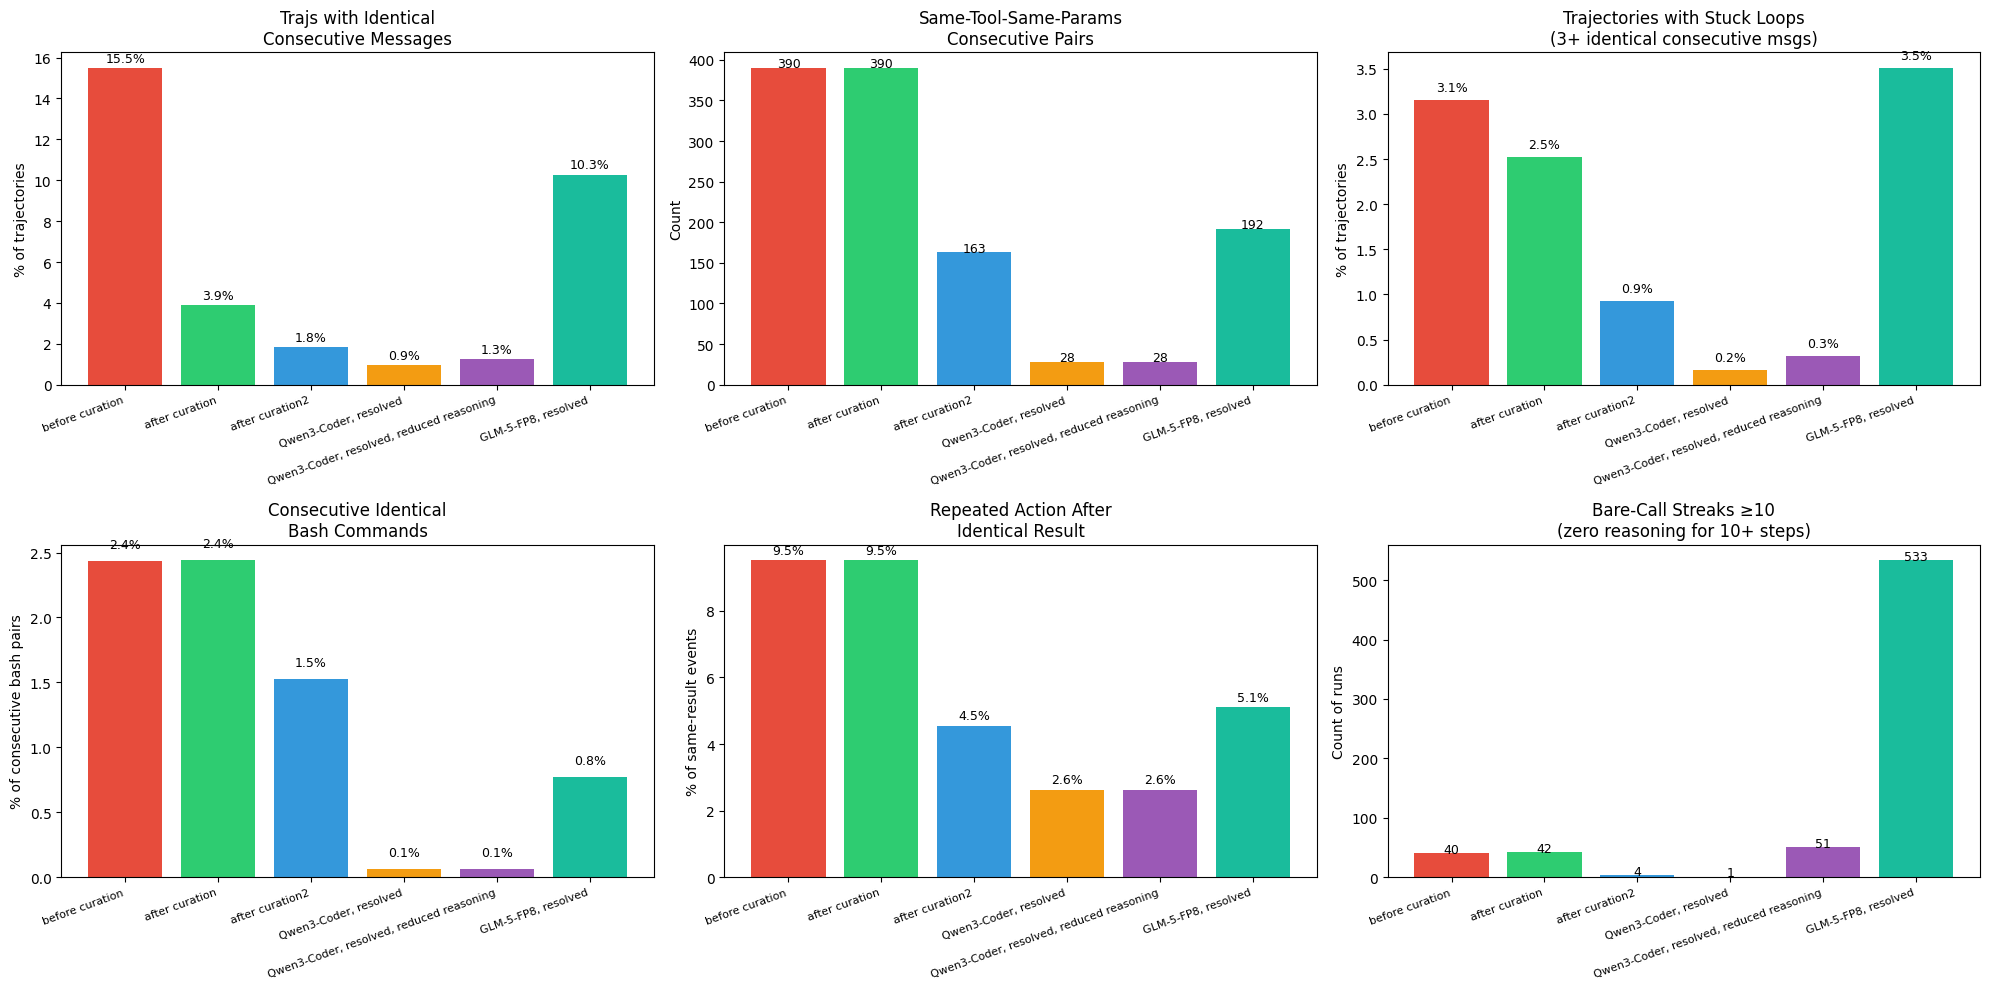

In [ ]:
# === Comprehensive repetition bar charts ===
rep_labels = [r['label'] for r in rep_results]
short_rep = [l.split('(')[1].rstrip(')') if '(' in l else l for l in rep_labels]
x_rep = range(len(rep_labels))
colors_rep = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c'][:len(rep_labels)]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

def _bar_chart(ax, vals, title, ylabel, fmt='{:.1f}%', is_pct=True):
    bars = ax.bar(x_rep, vals, color=colors_rep)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(list(x_rep))
    ax.set_xticklabels(short_rep, rotation=20, ha='right', fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals) * 0.02,
                fmt.format(v), ha='center', fontsize=9)

# Row 1: Whole-trajectory duplicates (% of asst msgs)
_bar_chart(axes[0, 0],
           [r['exact_reason_dups_pct'] for r in rep_results],
           'Exact Reasoning Duplicates\n(whole traj, % of asst msgs)',
           '% of asst msgs')

_bar_chart(axes[0, 1],
           [r['exact_tool_dups_pct'] for r in rep_results],
           'Exact Tool-Call Duplicates\n(whole traj, % of asst msgs)',
           '% of asst msgs')

_bar_chart(axes[0, 2],
           [r['near_reason_dups_pct'] for r in rep_results],
           f'Near-Dup Reasoning (≥{SIMILARITY_THRESHOLD})\n(whole traj, % of asst msgs)',
           '% of asst msgs')

_bar_chart(axes[0, 3],
           [r['near_tool_dups_pct'] for r in rep_results],
           f'Near-Dup Tool Calls (≥{SIMILARITY_THRESHOLD})\n(whole traj, % of asst msgs)',
           '% of asst msgs')

# Row 2: Traj-level and combined metrics
_bar_chart(axes[1, 0],
           [r['trajs_any_rep_pct'] for r in rep_results],
           'Trajs with ANY Repetition\n(exact or near, reason or tool)',
           '% of trajectories')

_bar_chart(axes[1, 1],
           [r['any_rep_msgs_pct'] for r in rep_results],
           'Repetitive Msgs (combined)\n(% of all asst msgs)',
           '% of asst msgs')

_bar_chart(axes[1, 2],
           [r['trajs_stuck_pct'] for r in rep_results],
           'Stuck Loops (3+ identical)\n(% of trajectories)',
           '% of trajectories')

_bar_chart(axes[1, 3],
           [r['bare_streak_ge10'] for r in rep_results],
           'Bare-Call Streaks ≥10\n(count of runs)',
           'Count', fmt='{:.0f}', is_pct=False)

plt.tight_layout()
plt.show()

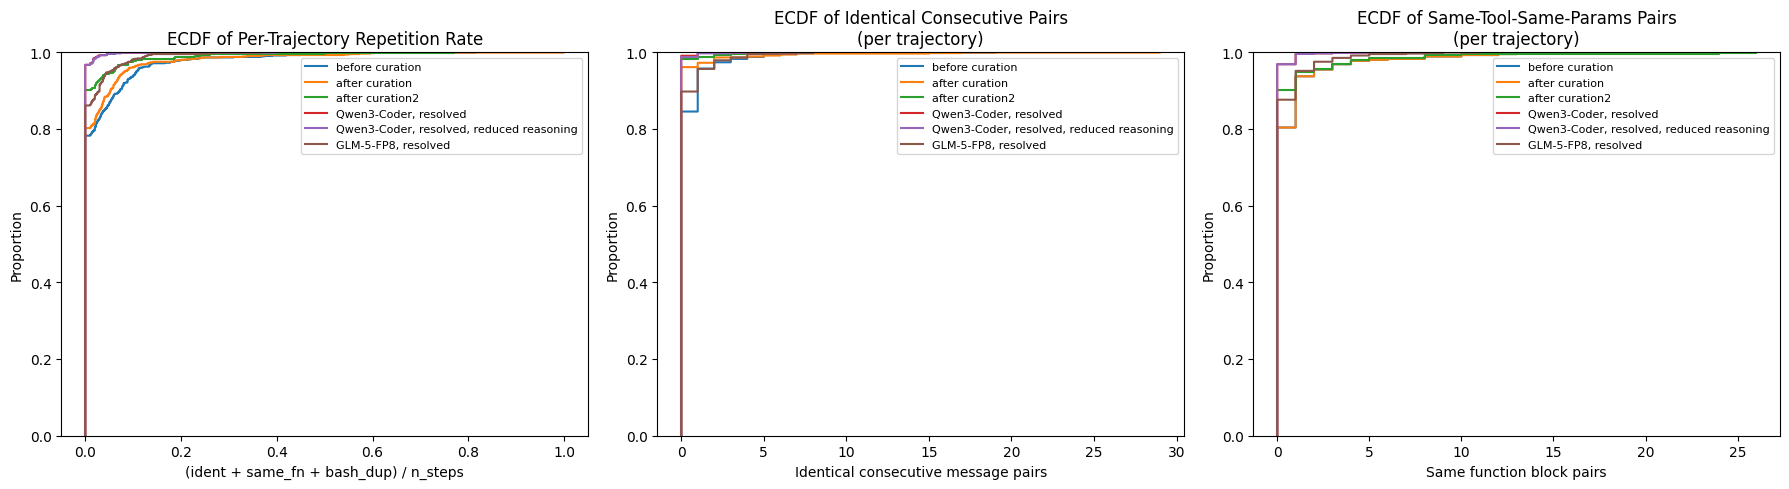


Per-trajectory repetition rate summary:
                                                     mean  50%     90%     max
label                                                                         
Oracle (after curation)                            0.0185  0.0  0.0526  1.0000
Oracle (after curation2)                           0.0100  0.0  0.0000  0.7692
Oracle (before curation)                           0.0212  0.0  0.0726  0.8154
Policy (GLM-5-FP8, resolved)                       0.0081  0.0  0.0300  0.3684
Policy (Qwen3-Coder, resolved)                     0.0014  0.0  0.0000  0.3667
Policy (Qwen3-Coder, resolved, reduced reasoning)  0.0015  0.0  0.0000  0.4000


In [ ]:
# === Per-trajectory repetition distributions (ECDF) ===
df_per_traj = pd.concat([pd.DataFrame(r['_per_traj']) for r in rep_results], ignore_index=True)

# Combined repetition score & rate
df_per_traj['total_dups'] = (
    df_per_traj['exact_reasoning_dups'] +
    df_per_traj['exact_tool_dups'] +
    df_per_traj['near_reasoning_dups'] +
    df_per_traj['near_tool_dups']
)
df_per_traj['dup_rate'] = df_per_traj['total_dups'] / df_per_traj['n_asst'].clip(lower=1)
df_per_traj['any_rep_rate'] = df_per_traj['any_rep_msgs'] / df_per_traj['n_asst'].clip(lower=1)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

def _ecdf(ax, col, title, xlabel):
    for lbl in df_per_traj['label'].unique():
        sub = df_per_traj[df_per_traj['label'] == lbl]
        short = lbl.split('(')[1].rstrip(')') if '(' in lbl else lbl
        sns.ecdfplot(data=sub, x=col, ax=ax, label=short)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=7)

# Row 1
_ecdf(axes[0, 0], 'any_rep_rate',
      'ECDF: Any-Repetition Rate', 'any_rep_msgs / n_steps')

_ecdf(axes[0, 1], 'exact_reasoning_dups',
      'ECDF: Exact Reasoning Dups\n(per trajectory)', 'Count')

_ecdf(axes[0, 2], 'exact_tool_dups',
      'ECDF: Exact Tool-Call Dups\n(per trajectory)', 'Count')

# Row 2
_ecdf(axes[1, 0], 'near_reasoning_dups',
      'ECDF: Near-Dup Reasoning\n(per trajectory)', 'Count')

_ecdf(axes[1, 1], 'near_tool_dups',
      'ECDF: Near-Dup Tool Calls\n(per trajectory)', 'Count')

_ecdf(axes[1, 2], 'consec_same_fn',
      'ECDF: Consecutive Same-FN Pairs\n(per trajectory)', 'Count')

plt.tight_layout()
plt.show()

# Summary stats
print('\nPer-trajectory any-repetition rate:')
print(df_per_traj.groupby('label')['any_rep_rate'].describe(
    percentiles=[.5, .9])[['mean', '50%', '90%', 'max']].round(4).to_string())

print('\nPer-trajectory total dups (exact+near, reasoning+tool):')
print(df_per_traj.groupby('label')['total_dups'].describe(
    percentiles=[.5, .9])[['mean', '50%', '90%', 'max']].round(1).to_string())

In [44]:
# === Concrete examples of repetition patterns ===

def show_repetition_examples(path: str, label: str, max_examples: int = 5):
    """Show concrete examples of the worst repetition patterns."""
    print(f'\n{"=" * 80}')
    print(f'  {label}')
    print(f'{"=" * 80}')

    shown_ident = 0
    shown_stuck = 0

    with open(path) as f:
        for traj_idx, line in enumerate(f):
            if shown_ident >= max_examples and shown_stuck >= max_examples:
                break
            d = json.loads(line)
            msgs = d['messages']
            asst_msgs = [(i, m) for i, m in enumerate(msgs) if m['role'] == 'assistant']

            # Find consecutive identical messages
            if shown_ident < max_examples:
                for j in range(1, len(asst_msgs)):
                    if shown_ident >= max_examples:
                        break
                    idx_a, m_a = asst_msgs[j - 1]
                    idx_b, m_b = asst_msgs[j]
                    if m_a['content'] == m_b['content']:
                        shown_ident += 1
                        fn_name = _extract_fn_name(m_a['content']) or '(no tool)'
                        preview = m_a['content'][:200].replace('\n', '\\n')
                        print(f'\n  [Identical #{shown_ident}] traj {traj_idx}, msg idx {idx_a} & {idx_b}, tool={fn_name}')
                        print(f'    Content: {preview}...')

            # Find stuck runs (3+ identical)
            if shown_stuck < max_examples:
                run = 1
                for j in range(1, len(asst_msgs)):
                    if asst_msgs[j][1]['content'] == asst_msgs[j - 1][1]['content']:
                        run += 1
                    else:
                        if run >= 3 and shown_stuck < max_examples:
                            shown_stuck += 1
                            start_idx = asst_msgs[j - run][0]
                            fn_name = _extract_fn_name(asst_msgs[j - 1][1]['content']) or '(no tool)'
                            preview = asst_msgs[j - 1][1]['content'][:150].replace('\n', '\\n')
                            print(f'\n  [Stuck x{run} #{shown_stuck}] traj {traj_idx}, starting at msg {start_idx}, tool={fn_name}')
                            print(f'    Content: {preview}...')
                        run = 1
                if run >= 3 and shown_stuck < max_examples:
                    shown_stuck += 1
                    start_idx = asst_msgs[len(asst_msgs) - run][0]
                    fn_name = _extract_fn_name(asst_msgs[-1][1]['content']) or '(no tool)'
                    preview = asst_msgs[-1][1]['content'][:150].replace('\n', '\\n')
                    print(f'\n  [Stuck x{run} #{shown_stuck}] traj {traj_idx}, starting at msg {start_idx}, tool={fn_name}')
                    print(f'    Content: {preview}...')


for label, path in FILES:
    show_repetition_examples(path, label, max_examples=3)


  Oracle (before curation)

  [Identical #1] traj 13, msg idx 92 & 94, tool=think
    Content: I found a bug in my implementation during verification testing. The test `test_scan_without_filter_expression()` failed because scan() uses an empty string as the default for ProjectionExpression. Let...

  [Identical #2] traj 13, msg idx 94 & 96, tool=think
    Content: I found a bug in my implementation during verification testing. The test `test_scan_without_filter_expression()` failed because scan() uses an empty string as the default for ProjectionExpression. Let...

  [Identical #3] traj 13, msg idx 96 & 98, tool=think
    Content: I found a bug in my implementation during verification testing. The test `test_scan_without_filter_expression()` failed because scan() uses an empty string as the default for ProjectionExpression. Let...

  [Stuck x4 #1] traj 13, starting at msg 92, tool=think
    Content: I found a bug in my implementation during verification testing. The test `test_scan_wi


  [Stuck x3 #1] traj 577, starting at msg 44, tool=task_tracker
    Content: <function=task_tracker>\n<parameter=command>view</parameter>\n</function>...

  [Stuck x4 #2] traj 577, starting at msg 54, tool=task_tracker
    Content: <function=task_tracker>\n<parameter=command>view</parameter>\n</function>...

  Policy (Qwen3-Coder, resolved, reduced reasoning)

  [Identical #1] traj 73, msg idx 102 & 104, tool=task_tracker
    Content: <function=task_tracker>\n<parameter=command>view</parameter>\n</function>...

  [Identical #2] traj 73, msg idx 104 & 106, tool=task_tracker
    Content: <function=task_tracker>\n<parameter=command>view</parameter>\n</function>...

  [Identical #3] traj 73, msg idx 106 & 108, tool=task_tracker
    Content: <function=task_tracker>\n<parameter=command>view</parameter>\n</function>...

  [Stuck x4 #1] traj 73, starting at msg 102, tool=task_tracker
    Content: <function=task_tracker>\n<parameter=command>view</parameter>\n</function>...

  [Stuck x3 #2] tra

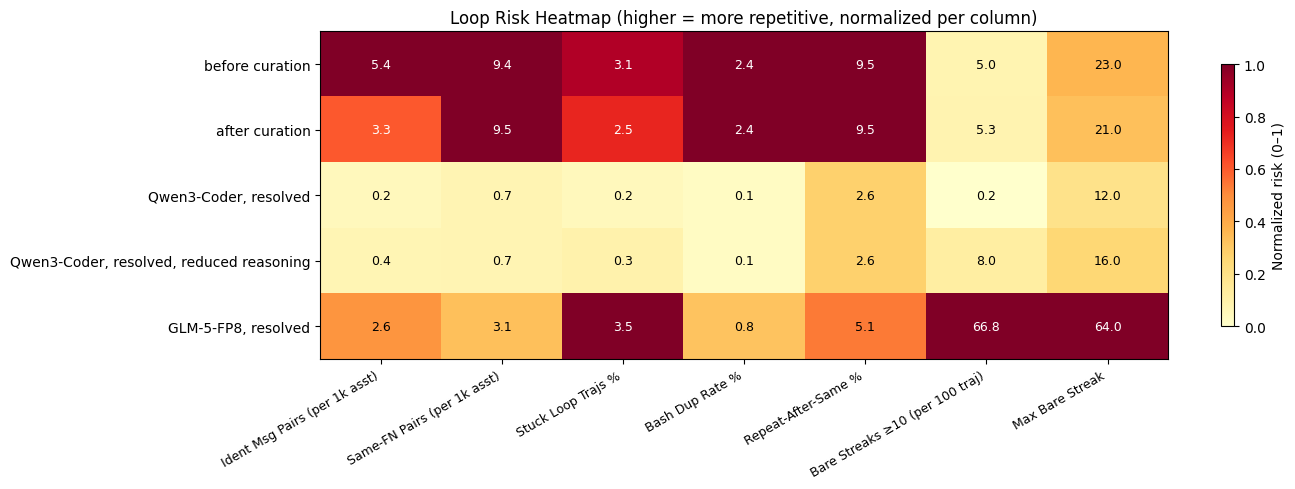


Raw risk metric values:


,Ident Msg Pairs (per 1k asst),Same-FN Pairs (per 1k asst),Stuck Loop Trajs %,Bash Dup Rate %,Repeat-After-Same %,Bare Streaks ≥10 (per 100 traj),Max Bare Streak
before curation,5.45,9.45,3.15,2.43,9.51,5.04,23.0
after curation,3.30,9.46,2.52,2.44,9.51,5.30,21.0
"Qwen3-Coder, resolved",0.25,0.69,0.16,0.06,2.62,0.16,12.0
"Qwen3-Coder, resolved, reduced reasoning",0.37,0.69,0.32,0.06,2.62,8.04,16.0
"GLM-5-FP8, resolved",2.56,3.13,3.51,0.77,5.10,66.79,64.0


In [ ]:
# === Loop Risk Heatmap (comprehensive) ===

risk_metrics = {
    'Exact Reason Dup %':  lambda r: r['exact_reason_dups_pct'],
    'Exact Tool Dup %':    lambda r: r['exact_tool_dups_pct'],
    'Near Reason Dup %':   lambda r: r['near_reason_dups_pct'],
    'Near Tool Dup %':     lambda r: r['near_tool_dups_pct'],
    'Any Rep Msgs %':      lambda r: r['any_rep_msgs_pct'],
    'Consec Same-FN':      lambda r: r['consec_same_fn'],
    'Stuck Loop Trajs %':  lambda r: r['trajs_stuck_pct'],
    'Bare Streaks ≥10':    lambda r: r['bare_streak_ge10'],
}

risk_data = {}
for r in rep_results:
    short = r['label'].split('(')[1].rstrip(')') if '(' in r['label'] else r['label']
    risk_data[short] = {k: fn(r) for k, fn in risk_metrics.items()}

df_risk = pd.DataFrame(risk_data).T

# Normalize per column
df_risk_norm = df_risk.copy()
for col in df_risk_norm.columns:
    col_max = df_risk_norm[col].max()
    if col_max > 0:
        df_risk_norm[col] = df_risk_norm[col] / col_max

fig, ax = plt.subplots(figsize=(16, max(3, len(rep_results) * 0.8 + 1)))
im = ax.imshow(df_risk_norm.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(df_risk.columns)))
ax.set_xticklabels(df_risk.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(df_risk.index)))
ax.set_yticklabels(df_risk.index, fontsize=10)

for i in range(len(df_risk.index)):
    for j in range(len(df_risk.columns)):
        val = df_risk.values[i, j]
        text = f'{val:.1f}' if val < 100 else f'{val:.0f}'
        color = 'white' if df_risk_norm.values[i, j] > 0.6 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=9, color=color)

ax.set_title('Loop Risk Heatmap — Comprehensive (normalized per column)', fontsize=12)
plt.colorbar(im, ax=ax, label='Normalized risk (0–1)', shrink=0.8)
plt.tight_layout()
plt.show()

print('\nRaw risk metric values:')
display(df_risk.round(2))

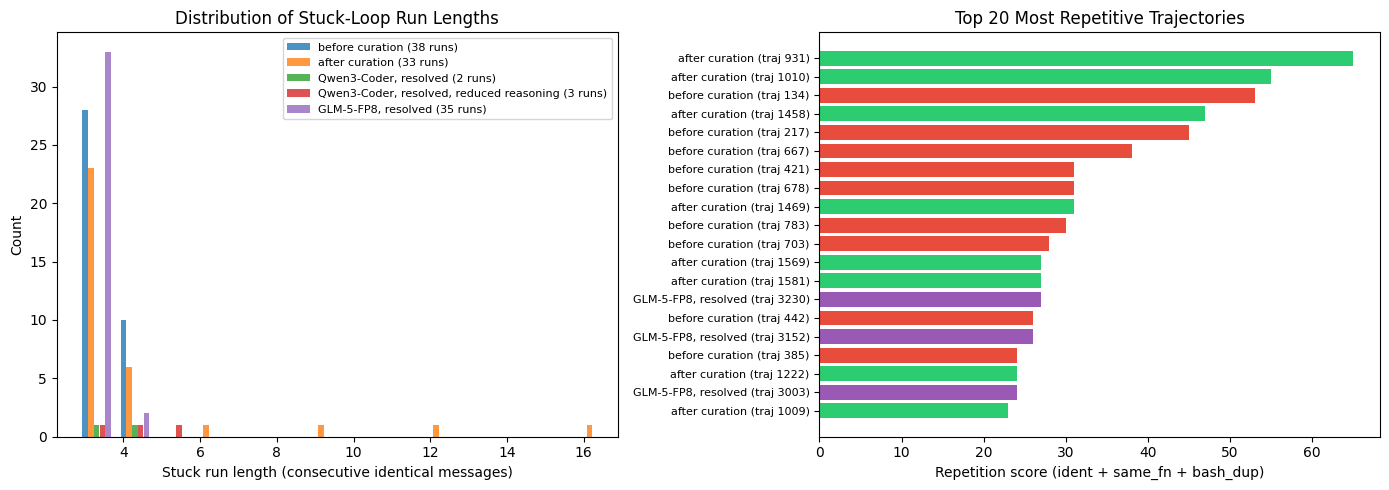


Top 20 most repetitive trajectories:
                             label  n_asst  ident_pairs  same_fn_pairs  bash_dup_pairs  same_result_repeated  repetition_score  repetition_rate
931        Oracle (after curation)      65           17             24              24                     0                65         1.000000
1010       Oracle (after curation)     100           29             26               0                     0                55         0.550000
134       Oracle (before curation)      65            5             24              24                     0                53         0.815385
1458       Oracle (after curation)      79           15             16              16                    11                47         0.594937
217       Oracle (before curation)     100           19             26               0                     0                45         0.450000
667       Oracle (before curation)      79            6             16              16            

In [ ]:
# === Worst trajectories by total repetition ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 25 by total_dups
ax = axes[0]
df_worst = df_per_traj.nlargest(25, 'total_dups')
short_labels_worst = [l.split('(')[1].rstrip(')') if '(' in l else l for l in df_worst['label']]
color_map = {lbl: colors_rep[idx % len(colors_rep)] for idx, lbl in enumerate(df_per_traj['label'].unique())}
bar_colors = [color_map[l] for l in df_worst['label']]
ax.barh(range(len(df_worst)), df_worst['total_dups'].values, color=bar_colors)
ax.set_yticks(range(len(df_worst)))
ax.set_yticklabels([f'{s} #{i}' for s, i in zip(short_labels_worst, df_worst.index)], fontsize=7)
ax.set_xlabel('Total duplicates (exact + near, reasoning + tool)')
ax.set_title('Top 25 Most Repetitive Trajectories')
ax.invert_yaxis()

# Right: breakdown stacked bar for top 25
ax = axes[1]
cols = ['exact_reasoning_dups', 'exact_tool_dups', 'near_reasoning_dups', 'near_tool_dups']
col_labels = ['Exact Reason', 'Exact Tool', 'Near Reason', 'Near Tool']
col_colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
bottom = [0] * len(df_worst)
for col, cl, cc in zip(cols, col_labels, col_colors):
    vals = df_worst[col].values
    ax.barh(range(len(df_worst)), vals, left=bottom, color=cc, label=cl, alpha=0.85)
    bottom = [b + v for b, v in zip(bottom, vals)]
ax.set_yticks(range(len(df_worst)))
ax.set_yticklabels([f'{s} #{i}' for s, i in zip(short_labels_worst, df_worst.index)], fontsize=7)
ax.set_xlabel('Count')
ax.set_title('Breakdown: Exact vs Near, Reasoning vs Tool')
ax.legend(fontsize=8, loc='lower right')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Print details
print('\nTop 25 most repetitive trajectories:')
display(df_per_traj.nlargest(25, 'total_dups')[
    ['label', 'n_asst', 'exact_reasoning_dups', 'exact_tool_dups',
     'near_reasoning_dups', 'near_tool_dups', 'total_dups', 'any_rep_rate']
].round(3))

In [45]:
# === Configure files to clean ===
# Add any trajectory JSONL paths here
CLEAN_FILES = [
    # GLM policy rollout
    f'{SFT_BASE}/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-train-glm5_fp8_t05-run_1/sft/policy_traj_128k_swegym_resolved_798i.jsonl',
    # Oracle (GLM-generated, before curation)
    f'{SFT_BASE}/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/sft/oracle_traj_128k_swegym_all_794i.jsonl',
    # Oracle (GLM-generated, after curation, from external curation run)
    "/home/v-murongma/code/oracle_generated_curation/curation_runs/oracle_traj_128k_swegym_all_794i_20260420_035513/oracle_traj_128k_swegym_all_794i_curated.jsonl",
    # Oracle (GLM-generated, after curation)
    f'{SFT_BASE}/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/sft/oracle_traj_128k_swegym_all_794i_curated.jsonl',
]

for p in CLEAN_FILES:
    exists = os.path.exists(p)
    size = os.path.getsize(p) / 1e6 if exists else 0
    name = os.path.basename(p)
    print(f"{'OK' if exists else 'MISSING':7s} {size:7.1f}MB  {name}")

OK        225.3MB  policy_traj_128k_swegym_resolved_798i.jsonl
OK        160.4MB  oracle_traj_128k_swegym_all_794i.jsonl
OK         87.9MB  oracle_traj_128k_swegym_all_794i_curated.jsonl
OK        156.2MB  oracle_traj_128k_swegym_all_794i_curated.jsonl


In [ ]:
def clean_trajectory(msgs: list[dict], near_threshold: float = 0.85) -> tuple[list[dict], dict]:
    """
    Remove repetitive assistant+user pairs from a message list.

    Rules (applied iteratively until stable):
      1. If assistant[i] has IDENTICAL reasoning OR tool-call to any EARLIER assistant → remove
      2. If assistant[i] has NEAR-DUPLICATE (similarity ≥ threshold) reasoning OR tool-call
         to the IMMEDIATELY PRECEDING assistant → remove
      3. Consecutive identical fn blocks → remove

    When removing: always delete the assistant msg AND the user msg right before it
    (the environment observation from the previous duplicate action).

    Returns: (cleaned_msgs, stats_dict)
    """
    stats = {
        'original_msgs': len(msgs),
        'removed_exact_reasoning': 0,
        'removed_exact_tool': 0,
        'removed_near_dup': 0,
        'removed_consec_fn': 0,
        'passes': 0,
    }

    cleaned = list(msgs)

    while True:
        stats['passes'] += 1
        indices_to_remove = set()

        # Collect assistant entries: (index_in_cleaned, reasoning, tool)
        asst_entries = []
        for i, m in enumerate(cleaned):
            if m['role'] == 'assistant':
                content = m.get('content', '') or ''
                reasoning, tool = _split_reasoning_and_tool(content)
                asst_entries.append((i, reasoning, tool))

        seen_reasoning = {}  # reasoning -> first seq index
        seen_tool = {}       # tool -> first seq index

        for seq, (idx, reasoning, tool) in enumerate(asst_entries):
            if idx in indices_to_remove:
                continue

            remove = False
            reason_tag = ''

            # Rule 1a: exact reasoning duplicate (whole traj, skip empty/trivial)
            if reasoning and len(reasoning) > 10 and reasoning in seen_reasoning:
                remove = True
                reason_tag = 'exact_reasoning'

            # Rule 1b: exact tool duplicate (whole traj)
            if not remove and tool and tool in seen_tool:
                remove = True
                reason_tag = 'exact_tool'

            # Rule 2: near-duplicate to immediately preceding assistant
            if not remove and seq > 0:
                prev_idx, prev_reasoning, prev_tool = asst_entries[seq - 1]
                if prev_idx not in indices_to_remove:
                    # Near-dup reasoning
                    if (reasoning and prev_reasoning and len(reasoning) > 20
                            and _normalized_similarity(reasoning, prev_reasoning) >= near_threshold):
                        remove = True
                        reason_tag = 'near_dup'
                    # Near-dup tool
                    if (not remove and tool and prev_tool and len(tool) > 20
                            and _normalized_similarity(tool, prev_tool) >= near_threshold):
                        remove = True
                        reason_tag = 'near_dup'

            # Rule 3: consecutive identical fn block (catches same tool even with different reasoning)
            if not remove and seq > 0:
                prev_idx, _, prev_tool = asst_entries[seq - 1]
                if prev_idx not in indices_to_remove and tool and prev_tool and tool == prev_tool:
                    remove = True
                    reason_tag = 'consec_fn'

            if remove:
                # Remove user msg before this assistant + this assistant
                user_idx = idx - 1
                if user_idx >= 0 and cleaned[user_idx]['role'] == 'user':
                    indices_to_remove.add(user_idx)
                indices_to_remove.add(idx)
                if reason_tag in ('exact_reasoning', 'exact_tool'):
                    stats[f'removed_{reason_tag}'] += 1
                elif reason_tag == 'near_dup':
                    stats['removed_near_dup'] += 1
                else:
                    stats['removed_consec_fn'] += 1
            else:
                # Only register in seen sets if we're keeping this message
                if reasoning and len(reasoning) > 10:
                    seen_reasoning.setdefault(reasoning, seq)
                if tool:
                    seen_tool.setdefault(tool, seq)

        if not indices_to_remove:
            break

        cleaned = [m for i, m in enumerate(cleaned) if i not in indices_to_remove]

    stats['cleaned_msgs'] = len(cleaned)
    stats['total_removed'] = stats['original_msgs'] - len(cleaned)
    return cleaned, stats


# --- Dry-run on all files to show impact ---
header = (f'{"File":<55s} {"Trajs":>5s} {"Orig":>7s} {"Clean":>7s} '
          f'{"Removed":>8s} {"ExReas":>6s} {"ExTool":>6s} {"Near":>5s} {"CsFN":>5s}')
print(header)
print('-' * len(header))

all_clean_results = {}
for path in CLEAN_FILES:
    name = os.path.basename(path)
    total_trajs = 0
    total_orig = 0
    total_clean = 0
    total_er = 0
    total_et = 0
    total_nd = 0
    total_cf = 0
    cleaned_entries = []

    with open(path) as f:
        for line in f:
            d = json.loads(line)
            total_trajs += 1
            cleaned_msgs, st = clean_trajectory(d['messages'])
            total_orig += st['original_msgs']
            total_clean += st['cleaned_msgs']
            total_er += st['removed_exact_reasoning']
            total_et += st['removed_exact_tool']
            total_nd += st['removed_near_dup']
            total_cf += st['removed_consec_fn']

            d_clean = dict(d)
            d_clean['messages'] = cleaned_msgs
            cleaned_entries.append(d_clean)

    total_removed = total_orig - total_clean
    print(f'{name:<55s} {total_trajs:>5d} {total_orig:>7d} {total_clean:>7d} '
          f'{total_removed:>7d} ({100*total_removed/max(total_orig,1):.1f}%) '
          f'{total_er:>5d} {total_et:>5d} {total_nd:>5d} {total_cf:>5d}')

    all_clean_results[path] = cleaned_entries

print(f'\nAll files processed. Ready to save.')

File                                                    Trajs  Orig Msgs  Clean Msgs  Removed  Ident  SameFN
--------------------------------------------------------------------------------------------------------------
policy_traj_128k_swegym_resolved_798i.jsonl               798     123624      123240     384 (0.3%)   157     35
oracle_traj_128k_swegym_all_794i.jsonl                    794      83382       82552     830 (1.0%)   225    190
oracle_traj_128k_swegym_all_794i_curated.jsonl            433      45578       45252     326 (0.7%)    21    142
oracle_traj_128k_swegym_all_794i_curated.jsonl            793      83257       82471     786 (0.9%)   136    257

All files processed. Ready to save.


In [47]:
# === Save cleaned trajectory files ===
# Output: same directory, filename gets '_dedup' before .jsonl

saved_paths = []
for orig_path, entries in all_clean_results.items():
    out_path = orig_path.replace('.jsonl', '_dedup.jsonl')
    with open(out_path, 'w') as f:
        for entry in entries:
            f.write(json.dumps(entry, ensure_ascii=False) + '\n')

    orig_size = os.path.getsize(orig_path) / 1e6
    new_size = os.path.getsize(out_path) / 1e6
    orig_name = os.path.basename(orig_path)
    new_name = os.path.basename(out_path)
    saved_paths.append(out_path)
    print(f'Saved: {new_name}')
    print(f'  {orig_size:.1f}MB → {new_size:.1f}MB  ({100*new_size/orig_size:.1f}% of original)')
    print(f'  {len(entries)} trajectories')
    print()

print('All cleaned files saved.')
for p in saved_paths:
    print(f'  {p}')

Saved: policy_traj_128k_swegym_resolved_798i_dedup.jsonl
  225.3MB → 222.4MB  (98.7% of original)
  798 trajectories

Saved: oracle_traj_128k_swegym_all_794i_dedup.jsonl
  160.4MB → 157.2MB  (98.0% of original)
  794 trajectories

Saved: oracle_traj_128k_swegym_all_794i_curated_dedup.jsonl
  87.9MB → 87.7MB  (99.7% of original)
  433 trajectories

Saved: oracle_traj_128k_swegym_all_794i_curated_dedup.jsonl
  156.2MB → 155.1MB  (99.3% of original)
  793 trajectories

All cleaned files saved.
  /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-train-glm5_fp8_t05-run_1/sft/policy_traj_128k_swegym_resolved_798i_dedup.jsonl
  /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/sft/oracle_traj_128k_swegym_all_794i_dedup.jsonl
  /home/v-murongma/cod